<a href="https://colab.research.google.com/github/tousifo/ml_notebooks/blob/main/QTrojan_BloodMNIST_QSentry_QXAI_Integrated_ResearchGrade_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QTrojan / BloodMNIST Detection, Model Audit, and Circuit Repair — 3 Seeds

This notebook contains **only Attack 1: QTrojan**. It detects circuit/model compromise via model-level audit and repairs the QTrojan circuit. Forced-`t=0` sample clustering is kept only as a leakage/null control, not as triggered-sample detection.

**Updated methodology note:** QXAI repair-mask selection uses validation source examples only; test data is reserved for final evaluation.

## Non-hardcoded result policy

Previous values such as CA=0.7025, ASR=0.9471, Repair ASR=0.0369, and Repair CA=0.8642 are treated as **verified in user-provided note only** unless regenerated by this notebook. Final tables are generated from runtime variables and saved as CSV/JSON.

The notebook must be rerun after this update because prior repair metrics used test-selected QXAI examples.

In [1]:

# ============================================================
# Imports, configuration, reproducibility
# Notebook 1: QTrojan / BloodMNIST only
# ============================================================

import os, sys, math, json, time, random, warnings, subprocess, copy
from dataclasses import dataclass, asdict
from typing import Optional, Tuple, Dict, Any, List
warnings.filterwarnings("ignore")

KAGGLE_T4_MODE = True
INSTALL_MISSING_PACKAGES = True

def ensure_package(import_name, pip_name=None):
    try:
        return __import__(import_name)
    except ImportError as exc:
        if not INSTALL_MISSING_PACKAGES:
            raise ImportError(f"Missing package '{import_name}'. Install it first. Original error: {exc}")
        pip_args = pip_name or import_name
        if isinstance(pip_args, str):
            pip_args = [pip_args]
        print(f"[install] Missing {import_name}; installing: {' '.join(pip_args)}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pip_args])
        return __import__(import_name)

np = ensure_package("numpy")
pd = ensure_package("pandas")
torch = ensure_package("torch")
torchvision = ensure_package("torchvision")
sklearn = ensure_package("sklearn", "scikit-learn")
medmnist = ensure_package("medmnist")
qml = ensure_package("pennylane", ["pennylane", "pennylane-lightning"])
matplotlib = ensure_package("matplotlib")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset
import torchvision.transforms as T
from torchvision import models
from torchvision.models import ResNet18_Weights
from medmnist import INFO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA, PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, auc, silhouette_score
)
import matplotlib.pyplot as plt
from IPython.display import display

DEFAULT_OUT_DIR = (
    "/kaggle/working/outputs_qtrojan_bloodmnist"
    if os.path.exists("/kaggle/working")
    else "/mnt/data/outputs_qtrojan_bloodmnist"
    if os.path.exists("/mnt/data")
    else "./outputs_qtrojan_bloodmnist"
)

RUN_QTROJAN_3SEED = True
SAVE_CHECKPOINTS = True

@dataclass
class QMedShieldConfig:
    # Scope lock
    attack_type: str = "qtrojan"
    dataset_name: str = "bloodmnist"

    # Reproducibility
    primary_seed: int = 42
    seeds: Tuple[int, ...] = (42, 123, 777)

    # Dataset
    n_classes: int = 8
    native_image_size: int = 28
    model_image_size: int = 96
    auto_resolve_class_ids: bool = True
    source_class: int = 1
    target_class: int = 6
    source_name_hint: str = "eosinophil"
    target_name_hint: str = "neutrophil"

    # Runtime caps
    max_train_n: int = 7000
    max_clean_test_n: int = 1200
    max_asr_n: int = 800
    val_size: float = 0.15

    # Architecture
    use_imagenet_weights: bool = True
    freeze_resnet_lower_blocks: bool = True
    n_qubits: int = 8
    vqc_layers: int = 4
    obs_mode: str = "ZX_ALT"
    trojan_init_std: float = 0.05

    # Training
    train_batch_size: int = 48
    eval_batch_size: int = 96
    clean_epochs: int = 10
    qtrojan_epochs: int = 14
    lr_base: float = 5e-4
    lr_trojan_mult: float = 3.0
    weight_decay: float = 1e-4
    label_smoothing: float = 0.10
    clean_acc_min: float = 0.70
    asr_min: float = 0.90
    strict_attack_gate: bool = False
    freeze_classical_in_trojan_stage: bool = True
    clean_loss_weight_trojan: float = 0.55
    q_loss_weight_trojan: float = 0.90
    qtrojan_source_boost_batches: int = 2

    # Leakage/null controls
    detection_pair_n: int = 500
    detection_backdoor_fraction: float = 0.10
    ica_components: int = 4
    k_clusters: int = 3
    kmeans_n_init: int = 10
    fpr_target: float = 0.05
    pair_same_images_for_qtrojan_detection: bool = True
    active_trigger_fraction: float = 0.10

    # QSentry-style activated QTrojan audit
    # Poison-rate sweep is generated from real validation/test source-class tensors.
    qsentry_poison_rates: Tuple[float, ...] = (0.01, 0.05, 0.10)
    qsentry_pool_n: int = 500
    qsentry_k_candidates: Tuple[int, ...] = (2, 3, 4, 5)
    qsentry_modes: Tuple[str, ...] = ("BLIND_T0", "ACTIVE_MIXED_T0_T1", "DELTA_ABS_T1_MINUS_T0")

    # QXAI / repair
    qxai_n_examples: int = 4
    repair_parameter_name: str = "trojan_angles"
    repair_top_k_pct: float = 0.15
    repair_finetune_epochs: int = 3
    repair_lr: float = 1e-4
    repair_strategies: Tuple[str, ...] = ("hard_reset",)
    repair_baseline_methods: Tuple[str, ...] = (
        "no_repair",
        "random_same_k_reset",
        "magnitude_same_k_reset",
        "gradient_same_k_reset",
        "qxai_same_k_reset",
        "full_trojan_angle_reset",
    )

    # Output
    out_dir: str = DEFAULT_OUT_DIR

cfg = QMedShieldConfig()
os.makedirs(cfg.out_dir, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NEEDS_VERIFICATION = []

# Known previous user-provided values are NOT hardcoded as final results.
# They are recorded only as non-authoritative reference notes until regenerated by this notebook.
USER_NOTE_REFERENCE = {
    "CA": "0.7025 — verified in user-provided note only",
    "ASR": "0.9471 — verified in user-provided note only",
    "Repair_ASR": "0.0369 — verified in user-provided note only",
    "Repair_CA": "0.8642 — verified in user-provided note only",
}

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(cfg.primary_seed)

print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("PennyLane:", qml.__version__)
print("Output directory:", cfg.out_dir)
print("User-note references are not final results:")
display(pd.DataFrame([USER_NOTE_REFERENCE]).T.rename(columns={0: "status"}))
display(pd.DataFrame([asdict(cfg)]).T.rename(columns={0: "value"}))


[install] Missing medmnist; installing: medmnist
[install] Missing pennylane; installing: pennylane pennylane-lightning
Device: cpu
Torch: 2.11.0+cpu
PennyLane: 0.45.0
Output directory: ./outputs_qtrojan_bloodmnist
User-note references are not final results:


,status
CA,0.7025 — verified in user-provided note only
ASR,0.9471 — verified in user-provided note only
Repair_ASR,0.0369 — verified in user-provided note only
Repair_CA,0.8642 — verified in user-provided note only


,value
attack_type,qtrojan
dataset_name,bloodmnist
primary_seed,42
seeds,"(42, 123, 777)"
n_classes,8
native_image_size,28
model_image_size,96
auto_resolve_class_ids,True
source_class,1
target_class,6


100%|██████████| 35.5M/35.5M [00:01<00:00, 21.3MB/s]


,class_id,class_name
0,0,basophil
1,1,eosinophil
2,2,erythroblast
3,3,"immature granulocytes(myelocytes, metamyelocyt..."
4,4,lymphocyte
5,5,monocyte
6,6,neutrophil
7,7,platelet


Final source class: 1 | eosinophil
Final target class: 6 | neutrophil
Shapes: torch.Size([11959, 3, 28, 28]) torch.Size([1712, 3, 28, 28]) torch.Size([3421, 3, 28, 28])


split,test,train,val
class_id,,,
0,244,852,122
1,624,2181,312
2,311,1085,155
3,579,2026,290
4,243,849,122
5,284,993,143
6,666,2330,333
7,470,1643,235


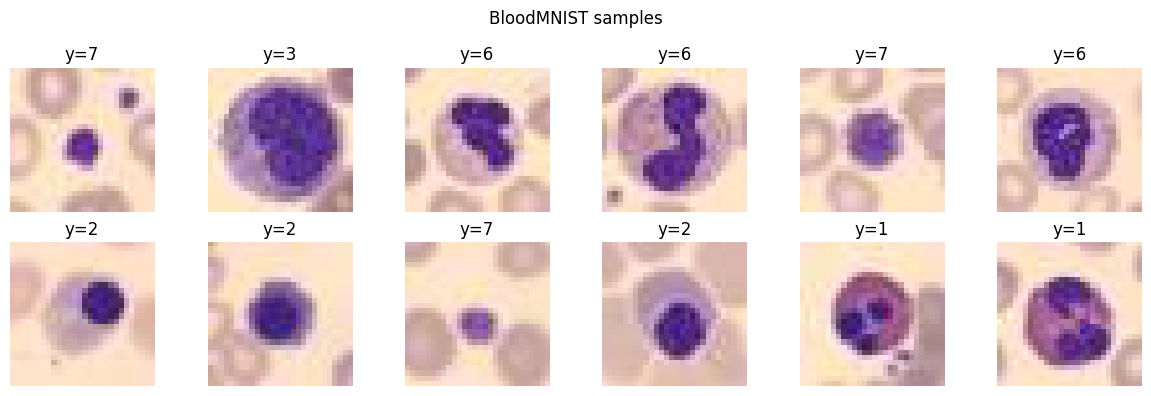

In [2]:
# ============================================================
# S2. DATASET LOADING + VALIDATION
# ============================================================

def load_medmnist_split(dataset_name: str, split: str, download: bool = True):
    if dataset_name not in INFO:
        raise ValueError(f"Unknown MedMNIST dataset: {dataset_name}")
    info = INFO[dataset_name]
    DataClass = getattr(medmnist, info["python_class"])
    ds = DataClass(split=split, download=download)

    imgs = np.asarray(ds.imgs)
    labels = np.asarray(ds.labels).reshape(-1).astype(np.int64)

    if imgs.ndim == 3:
        imgs = imgs[..., None]
    if imgs.shape[-1] == 1:
        imgs = np.repeat(imgs, 3, axis=-1)
    if imgs.shape[-1] != 3:
        raise ValueError(f"Expected RGB/grayscale data, got {imgs.shape}")

    X = torch.tensor(imgs, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    y = torch.tensor(labels, dtype=torch.long)
    return X, y, info

def label_map_to_int(label_map):
    out = {}
    for k, v in label_map.items():
        try:
            out[int(k)] = str(v)
        except Exception:
            pass
    return dict(sorted(out.items()))

def resolve_class_id(label_map, hint, fallback, role):
    matches = [i for i, name in label_map.items() if hint.lower() in name.lower()]
    if len(matches) == 1:
        resolved = int(matches[0])
        if resolved != fallback:
            print(f"[class-id correction] {role}: configured {fallback}, metadata resolves '{hint}' -> {resolved}")
        return resolved
    msg = f"needs verification: could not uniquely resolve {role}='{hint}'. Using fallback id={fallback}."
    print("[warning]", msg)
    NEEDS_VERIFICATION.append(msg)
    return int(fallback)

X_train_raw, y_train_raw, dataset_info = load_medmnist_split(cfg.dataset_name, "train", download=True)
X_val_official, y_val_official, _ = load_medmnist_split(cfg.dataset_name, "val", download=True)
X_test_raw, y_test_raw, _ = load_medmnist_split(cfg.dataset_name, "test", download=True)

label_map = label_map_to_int(dataset_info.get("label", {}))
display(pd.DataFrame({"class_id": list(label_map.keys()), "class_name": list(label_map.values())}))

if len(label_map) != cfg.n_classes:
    msg = f"needs verification: expected {cfg.n_classes} classes, found {len(label_map)} in metadata."
    print("[warning]", msg)
    NEEDS_VERIFICATION.append(msg)

if cfg.auto_resolve_class_ids:
    cfg.source_class = resolve_class_id(label_map, cfg.source_name_hint, cfg.source_class, "source")
    cfg.target_class = resolve_class_id(label_map, cfg.target_name_hint, cfg.target_class, "target")

if cfg.source_class == cfg.target_class:
    raise ValueError("Source and target classes are identical. Fix cfg.source_class/cfg.target_class.")

print(f"Final source class: {cfg.source_class} | {label_map.get(cfg.source_class, 'unknown')}")
print(f"Final target class: {cfg.target_class} | {label_map.get(cfg.target_class, 'unknown')}")
print("Shapes:", X_train_raw.shape, X_val_official.shape, X_test_raw.shape)

def class_count_table(y, split):
    counts = pd.Series(y.cpu().numpy()).value_counts().sort_index()
    return pd.DataFrame({"split": split, "class_id": counts.index, "count": counts.values})

dist_df = pd.concat([
    class_count_table(y_train_raw, "train"),
    class_count_table(y_val_official, "val"),
    class_count_table(y_test_raw, "test"),
], ignore_index=True)
display(dist_df.pivot_table(index="class_id", columns="split", values="count", fill_value=0).astype(int))

def show_image_grid(X, y, n=12, title="Sample images"):
    n = min(n, len(X))
    cols = min(n, 6)
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols * 2, rows * 2))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(X[i].permute(1, 2, 0).cpu().numpy())
        plt.title(f"y={int(y[i])}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_image_grid(X_train_raw, y_train_raw, n=12, title="BloodMNIST samples")


In [3]:

# ============================================================
# Scope and leakage assertions
# ============================================================
assert cfg.dataset_name.lower() == "bloodmnist", "Notebook 1 must use BloodMNIST only."
assert cfg.attack_type == "qtrojan", "Notebook 1 must run QTrojan only."
assert cfg.source_class is not None
assert cfg.target_class is not None
assert len(cfg.seeds) == 3, "Notebook 1 requires exactly 3 configured seeds."
assert cfg.n_qubits == 8
assert cfg.vqc_layers == 4
assert cfg.obs_mode == "ZX_ALT"
print("Scope assertions passed: BloodMNIST / QTrojan / 3 seeds / 8-qubit VQC.")


Scope assertions passed: BloodMNIST / QTrojan / 3 seeds / 8-qubit VQC.


In [4]:
# ============================================================
# S3-S7. MODEL + TRAINING HELPERS
# ============================================================

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)

def preprocess_for_resnet(x, model_image_size):
    x = F.interpolate(x, size=(model_image_size, model_image_size), mode="bilinear", align_corners=False)
    return (x - IMAGENET_MEAN.to(x.device)) / IMAGENET_STD.to(x.device)

def measurement_dim(n_qubits, obs_mode):
    obs = obs_mode.upper().strip()
    if obs in ["Z_ONLY", "ZX_ALT"]:
        return n_qubits
    if obs == "XYZ":
        return 3 * n_qubits
    raise ValueError(f"Unknown obs_mode={obs_mode}")

def make_vqc_qnode(n_qubits, n_layers, obs_mode="ZX_ALT"):
    try:
        dev = qml.device("lightning.qubit", wires=n_qubits)
    except Exception:
        print("[warning] lightning.qubit unavailable; using default.qubit")
        dev = qml.device("default.qubit", wires=n_qubits)
    obs = obs_mode.upper().strip()

    @qml.qnode(dev, interface="torch", diff_method="best")
    def circuit(angles, weights, input_scales, input_bias, trojan_angles, trigger_flag):
        for layer in range(n_layers):
            for q in range(n_qubits):
                qml.Rot(weights[layer, q, 0], weights[layer, q, 1], weights[layer, q, 2], wires=q)
            for q in range(n_qubits):
                qml.RY(input_scales[layer, q] * angles[q] + input_bias[layer, q], wires=q)

            # Critical isolation: trigger_flag=0 disables the inserted QTrojan RY gate.
            for q in range(n_qubits):
                qml.RY(trigger_flag * trojan_angles[layer, q], wires=q)

            if layer % 2 == 0:
                for q in range(n_qubits):
                    qml.CNOT(wires=[q, (q + 1) % n_qubits])
            else:
                for q in range(n_qubits):
                    qml.CNOT(wires=[(q + 1) % n_qubits, q])

        if obs == "Z_ONLY":
            return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
        if obs == "XYZ":
            out = []
            for q in range(n_qubits):
                out.extend([qml.expval(qml.PauliX(q)), qml.expval(qml.PauliY(q)), qml.expval(qml.PauliZ(q))])
            return out
        return [qml.expval(qml.PauliZ(q)) if q % 2 == 0 else qml.expval(qml.PauliX(q)) for q in range(n_qubits)]
    return circuit

class StrongVQCMeasurementLayer(nn.Module):
    def __init__(self, in_dim, n_qubits, n_layers, obs_mode, trojan_init_std):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.obs_mode = obs_mode
        self.compress = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, 32),
            nn.Tanh(),
            nn.Linear(32, n_qubits),
            nn.Tanh(),
        )
        self.weights = nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, 3))
        self.input_scales = nn.Parameter(torch.ones(n_layers, n_qubits))
        self.input_bias = nn.Parameter(torch.zeros(n_layers, n_qubits))
        self.trojan_angles = nn.Parameter(trojan_init_std * torch.randn(n_layers, n_qubits))
        self.qnode = make_vqc_qnode(n_qubits, n_layers, obs_mode)

    def forward(self, context, trojan_mask=None):
        angles = math.pi * (self.compress(context) + 1.0) / 2.0
        if trojan_mask is None:
            trojan_mask = torch.zeros(angles.shape[0], device=angles.device, dtype=angles.dtype)
        else:
            trojan_mask = trojan_mask.to(device=angles.device, dtype=angles.dtype).view(-1)

        vals = [
            torch.stack(self.qnode(a, self.weights, self.input_scales, self.input_bias, self.trojan_angles, flag)).float()
            for a, flag in zip(angles, trojan_mask)
        ]
        return torch.stack(vals, dim=0)

class QMedShieldHybridQNN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        weights = None
        if cfg.use_imagenet_weights:
            try:
                weights = ResNet18_Weights.IMAGENET1K_V1
            except Exception:
                weights = None
        try:
            resnet = models.resnet18(weights=weights)
        except Exception as exc:
            msg = f"needs verification: ImageNet weights unavailable ({exc}); using random ResNet-18 init."
            print("[warning]", msg)
            NEEDS_VERIFICATION.append(msg)
            resnet = models.resnet18(weights=None)

        self.stem = nn.Sequential(*list(resnet.children())[:-2])
        if cfg.freeze_resnet_lower_blocks:
            for p in self.stem[:6].parameters():
                p.requires_grad = False

        self.rnn = nn.GRU(input_size=512, hidden_size=256, num_layers=2,
                          batch_first=True, bidirectional=True, dropout=0.2)
        self.vqc = StrongVQCMeasurementLayer(512, cfg.n_qubits, cfg.vqc_layers, cfg.obs_mode, cfg.trojan_init_std)
        self.q_head = nn.Linear(measurement_dim(cfg.n_qubits, cfg.obs_mode), cfg.n_classes)

    def _context(self, x_preprocessed):
        feats = self.stem(x_preprocessed)
        B, C, H, W = feats.shape
        seq = feats.view(B, C, H*W).permute(0, 2, 1)
        out, _ = self.rnn(seq)
        return out.mean(dim=1)

    def _mask(self, batch_size, device, t=0.0, trojan_mask=None):
        if trojan_mask is not None:
            return trojan_mask.to(device=device, dtype=torch.float32).view(-1)
        if isinstance(t, torch.Tensor):
            return t.to(device=device, dtype=torch.float32).view(-1)
        return torch.full((batch_size,), float(t), device=device, dtype=torch.float32)

    def forward(self, x_preprocessed, t=0.0, return_measurements=False, trojan_mask=None):
        ctx = self._context(x_preprocessed)
        mask = self._mask(ctx.shape[0], ctx.device, t=t, trojan_mask=trojan_mask)
        qfeat = self.vqc(ctx, trojan_mask=mask)
        logits = self.q_head(qfeat)
        if return_measurements:
            return logits, qfeat, ctx
        return logits

    @torch.no_grad()
    def extract_vqc_measurements(self, x_raw, t=0.0):
        xp = preprocess_for_resnet(x_raw, self.cfg.model_image_size)
        _, qfeat, _ = self.forward(xp, t=t, return_measurements=True)
        return qfeat

def verify_architecture(model, cfg, device):
    model = model.to(device)
    dummy = torch.rand(4, 3, cfg.native_image_size, cfg.native_image_size, device=device)
    xp = preprocess_for_resnet(dummy, cfg.model_image_size)
    logits, qfeat, ctx = model(xp, t=0, return_measurements=True)
    assert logits.shape == (4, cfg.n_classes), logits.shape
    assert qfeat.shape == (4, measurement_dim(cfg.n_qubits, cfg.obs_mode)), qfeat.shape
    assert ctx.shape == (4, 512), ctx.shape
    print("Architecture verified:", logits.shape, qfeat.shape, ctx.shape)

def stratified_limit_tensors(X, y, max_n, seed):
    if max_n is None or len(y) <= max_n:
        return X, y, np.arange(len(y))
    idx = np.arange(len(y))
    _, keep = train_test_split(idx, test_size=max_n, random_state=seed, stratify=y.cpu().numpy())
    keep = np.sort(keep)
    return X[keep], y[keep], keep

def make_train_val_split(X, y, cfg, seed):
    X_lim, y_lim, keep = stratified_limit_tensors(X, y, cfg.max_train_n, seed)
    idx = np.arange(len(y_lim))
    tr, va = train_test_split(idx, test_size=cfg.val_size, random_state=seed, stratify=y_lim.cpu().numpy())
    tr, va = np.sort(tr), np.sort(va)
    return {"X_train": X_lim[tr], "y_train": y_lim[tr], "X_val": X_lim[va], "y_val": y_lim[va], "source_idx": keep}

def augment_train_only(X, seed):
    set_all_seeds(seed)
    aug = T.Compose([T.RandomHorizontalFlip(p=0.5), T.RandomCrop(X.shape[-1], padding=2, padding_mode="reflect")])
    return torch.stack([aug(img) for img in X])

def make_loader(X, y, batch_size, shuffle):
    return DataLoader(TensorDataset(X.float(), y.long()), batch_size=batch_size, shuffle=shuffle, num_workers=0)

def set_trainable(module, trainable):
    for p in module.parameters():
        p.requires_grad = trainable

def optimizer_for_stage(model, cfg, stage):
    if stage == "trojan":
        params = []
        params.append({"params": [model.vqc.trojan_angles], "lr": cfg.lr_base * cfg.lr_trojan_mult})
        other_vqc = [p for n, p in model.vqc.named_parameters() if n != "trojan_angles" and p.requires_grad]
        if other_vqc:
            params.append({"params": other_vqc, "lr": cfg.lr_base})
        params.append({"params": model.q_head.parameters(), "lr": cfg.lr_base})
        return torch.optim.AdamW(params, weight_decay=cfg.weight_decay)

    return torch.optim.AdamW([
        {"params": model.stem[6:].parameters(), "lr": cfg.lr_base * 0.1},
        {"params": model.rnn.parameters(), "lr": cfg.lr_base},
        {"params": model.vqc.parameters(), "lr": cfg.lr_base},
        {"params": model.q_head.parameters(), "lr": cfg.lr_base},
    ], weight_decay=cfg.weight_decay)

@torch.no_grad()
def evaluate_classifier(model, X, y, cfg, device, trojan_t=0.0):
    model.eval()
    loader = make_loader(X, y, cfg.eval_batch_size, shuffle=False)
    preds, probs = [], []
    for xb, _ in loader:
        xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
        logits = model(xb, t=trojan_t)
        prob = torch.softmax(logits, dim=1).cpu().numpy()
        preds.append(prob.argmax(axis=1))
        probs.append(prob)
    preds = np.concatenate(preds)
    probs = np.concatenate(probs)
    y_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.asarray(y)
    return {
        "accuracy": float(accuracy_score(y_np, preds)),
        "macro_f1": float(f1_score(y_np, preds, average="macro", zero_division=0)),
        "preds": preds,
        "probs": probs,
    }

@torch.no_grad()
def evaluate_qtrojan_asr(model, X, y, cfg, device, seed):
    y_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.asarray(y)
    idx = np.where(y_np == cfg.source_class)[0]
    if len(idx) == 0:
        raise ValueError("No source-class samples for ASR.")
    rng = np.random.default_rng(seed)
    if cfg.max_asr_n and len(idx) > cfg.max_asr_n:
        idx = rng.choice(idx, size=cfg.max_asr_n, replace=False)
    idx = np.sort(idx)
    y_target = torch.full((len(idx),), cfg.target_class, dtype=torch.long)
    out = evaluate_classifier(model, X[idx], y_target, cfg, device, trojan_t=1.0)
    out["n_source_eval"] = int(len(idx))
    return out

def train_clean_stage(model, train_loader, val_loader, cfg, device):
    model = model.to(device)
    opt = optimizer_for_stage(model, cfg, "clean")
    hist = []
    print(f"Stage A clean training: {cfg.clean_epochs} epochs")
    for ep in range(1, cfg.clean_epochs + 1):
        model.train()
        loss_sum, n = 0.0, 0
        for xb, yb in train_loader:
            xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
            yb = yb.to(device)
            opt.zero_grad()
            logits = model(xb, t=0.0)
            loss = F.cross_entropy(logits, yb, label_smoothing=cfg.label_smoothing)
            loss.backward()
            opt.step()
            loss_sum += float(loss.detach().cpu()) * len(xb)
            n += len(xb)
        val = evaluate_classifier(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], cfg, device, 0.0)
        row = {"epoch": ep, "stage": "clean", "loss": loss_sum/max(n,1), "val_acc": val["accuracy"], "val_macro_f1": val["macro_f1"]}
        hist.append(row)
        print(f"Epoch {ep:02d}: loss={row['loss']:.4f}, val_CA={row['val_acc']:.4f}")
    return model, hist

def train_qtrojan_stage(model, train_loader, val_loader, cfg, device):
    """
    QTrojan optimization stage.

    The previous short run underfit the attack (ASR below the configured gate).
    This version keeps the classical encoder frozen by default, but adds a small
    source-only trigger boost so every epoch sees enough source->target attack
    signal without making the notebook too heavy for Kaggle T4.
    """
    model = model.to(device)
    if cfg.freeze_classical_in_trojan_stage:
        set_trainable(model.stem, False)
        set_trainable(model.rnn, False)
        print("Frozen ResNet/BiGRU during QTrojan stage.")
    set_trainable(model.vqc, True)
    set_trainable(model.q_head, True)

    # Source-only loader for stable trigger optimization.
    X_all, y_all = train_loader.dataset.tensors
    src_mask = (y_all == cfg.source_class)
    if int(src_mask.sum()) == 0:
        raise ValueError("No source-class samples in training split; cannot train QTrojan.")
    src_dataset = TensorDataset(X_all[src_mask], y_all[src_mask])
    src_loader = DataLoader(
        src_dataset,
        batch_size=min(cfg.train_batch_size, len(src_dataset)),
        shuffle=True,
        drop_last=False
    )

    opt = optimizer_for_stage(model, cfg, "trojan")
    hist = []
    print(f"Stage B QTrojan training: {cfg.qtrojan_epochs} epochs")
    for ep in range(1, cfg.qtrojan_epochs + 1):
        model.train()
        loss_sum, n, tbatches = 0.0, 0, 0

        # Mixed clean + in-batch source attack pass.
        for xb, yb in train_loader:
            xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
            yb = yb.to(device)
            opt.zero_grad()

            logits_clean = model(xb, t=0.0)
            loss_clean = F.cross_entropy(logits_clean, yb, label_smoothing=cfg.label_smoothing)

            src_idx = torch.where(yb == cfg.source_class)[0]
            if len(src_idx) > 0:
                target = torch.full((len(src_idx),), cfg.target_class, dtype=torch.long, device=device)
                logits_trig = model(xb[src_idx], t=1.0)
                loss_trig = F.cross_entropy(logits_trig, target)
                loss = cfg.clean_loss_weight_trojan * loss_clean + cfg.q_loss_weight_trojan * loss_trig
                tbatches += 1
            else:
                loss = cfg.clean_loss_weight_trojan * loss_clean

            loss.backward()
            opt.step()
            loss_sum += float(loss.detach().cpu()) * len(xb)
            n += len(xb)

        # Lightweight source-only trigger boost. This usually improves ASR
        # without unfreezing the full ResNet/BiGRU stack.
        if cfg.qtrojan_source_boost_batches > 0:
            for b_i, (xs, _) in enumerate(src_loader):
                if b_i >= cfg.qtrojan_source_boost_batches:
                    break
                xs = preprocess_for_resnet(xs.to(device), cfg.model_image_size)
                target = torch.full((len(xs),), cfg.target_class, dtype=torch.long, device=device)
                opt.zero_grad()
                logits_trig = model(xs, t=1.0)
                loss_boost = cfg.q_loss_weight_trojan * F.cross_entropy(logits_trig, target)
                loss_boost.backward()
                opt.step()
                loss_sum += float(loss_boost.detach().cpu()) * len(xs)
                n += len(xs)
                tbatches += 1

        val_ca = evaluate_classifier(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], cfg, device, 0.0)
        val_asr = evaluate_qtrojan_asr(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], cfg, device, cfg.primary_seed)
        row = {"epoch": ep, "stage": "qtrojan", "loss": loss_sum/max(n,1), "val_ca": val_ca["accuracy"], "val_asr": val_asr["accuracy"], "trojan_batches": tbatches}
        hist.append(row)
        print(f"Epoch {ep:02d}: loss={row['loss']:.4f}, val_CA={row['val_ca']:.4f}, val_ASR={row['val_asr']:.4f}")
        if val_ca["accuracy"] >= cfg.clean_acc_min and val_asr["accuracy"] >= cfg.asr_min:
            print("Early stop: CA/ASR gates reached.")
            break
    return model, hist


In [5]:
# ============================================================
# S8-S13. QTROJAN PIPELINE + CC-QMC DETECTION
# ============================================================

@torch.no_grad()
def extract_measurements_and_context(model, X, cfg, device, trojan_mask_np=None, t_forced=None):
    model.eval()
    if t_forced is not None:
        masks = torch.full((len(X),), float(t_forced), dtype=torch.float32)
    elif trojan_mask_np is not None:
        masks = torch.tensor(trojan_mask_np, dtype=torch.float32)
    else:
        masks = torch.zeros(len(X), dtype=torch.float32)
    qs, ctxs, preds = [], [], []
    for s in range(0, len(X), cfg.eval_batch_size):
        e = min(s + cfg.eval_batch_size, len(X))
        xb = preprocess_for_resnet(X[s:e].to(device), cfg.model_image_size)
        tb = masks[s:e].to(device)
        logits, qfeat, ctx = model(xb, trojan_mask=tb, return_measurements=True)
        qs.append(qfeat.cpu())
        ctxs.append(ctx.cpu())
        preds.append(logits.argmax(dim=1).cpu())
    return torch.cat(qs).numpy(), torch.cat(ctxs).numpy(), torch.cat(preds).numpy()

@torch.no_grad()
def extract_delta_measurements(model, X, cfg, device):
    model.eval()
    feats, ctxs = [], []
    for s in range(0, len(X), cfg.eval_batch_size):
        e = min(s + cfg.eval_batch_size, len(X))
        xb = preprocess_for_resnet(X[s:e].to(device), cfg.model_image_size)
        b = xb.shape[0]
        zeros = torch.zeros(b, device=device)
        ones = torch.ones(b, device=device)
        _, q0, ctx = model(xb, trojan_mask=zeros, return_measurements=True)
        _, q1, _ = model(xb, trojan_mask=ones, return_measurements=True)
        feats.append(torch.cat([q0, q1, torch.abs(q1-q0)], dim=1).cpu())
        ctxs.append(ctx.cpu())
    return torch.cat(feats).numpy(), torch.cat(ctxs).numpy()

def build_detection_pool(X_test, y_test, cfg, seed):
    """
    Plan-aligned detection pool:
    clean-source + clean-target + all remaining source samples as logical triggered-source.

    This avoids the older 10% anomaly shortcut and makes the pool composition explicit.
    If a class has fewer than 500 examples, the function uses the largest feasible balanced count.
    """
    y_np = y_test.cpu().numpy()
    source_idx = np.where(y_np == cfg.source_class)[0]
    target_idx = np.where(y_np == cfg.target_class)[0]
    if len(source_idx) < 20 or len(target_idx) < 10:
        raise ValueError(
            f"Insufficient source/target samples: source={len(source_idx)}, target={len(target_idx)}"
        )

    rng = np.random.default_rng(seed)
    sp = rng.permutation(source_idx)
    tp = rng.permutation(target_idx)

    # Need enough source samples left for logical triggered-source.
    clean_n = min(cfg.detection_pair_n, len(target_idx), max(1, len(source_idx) // 2))
    clean_source_idx = sp[:clean_n]
    backdoor_source_idx = sp[clean_n:]     # all remaining source samples are trigger-test candidates
    clean_target_idx = tp[:clean_n]

    if len(backdoor_source_idx) < 1:
        raise ValueError("Detection pool has no logical backdoor source samples after clean-source allocation.")

    X_det = torch.cat(
        [X_test[clean_source_idx], X_test[clean_target_idx], X_test[backdoor_source_idx]],
        dim=0
    )

    is_backdoor = np.concatenate([
        np.zeros(len(clean_source_idx), dtype=bool),
        np.zeros(len(clean_target_idx), dtype=bool),
        np.ones(len(backdoor_source_idx), dtype=bool),
    ])

    group_names = np.array(
        ["clean_source"] * len(clean_source_idx)
        + ["clean_target"] * len(clean_target_idx)
        + ["logical_backdoor_source"] * len(backdoor_source_idx)
    )

    mask_t0 = np.zeros(len(X_det), dtype=np.float32)
    mask_trigger_diag = is_backdoor.astype(np.float32)

    print(
        f"Detection pool: {len(clean_source_idx)} clean-source + "
        f"{len(clean_target_idx)} clean-target + "
        f"{len(backdoor_source_idx)} logical-backdoor-source = {len(X_det)}"
    )
    return {
        "X_det": X_det,
        "is_backdoor": is_backdoor,
        "group_names": group_names,
        "mask_t0": mask_t0,
        "mask_trigger_diag": mask_trigger_diag,
    }


def build_paired_active_qtrojan_pool(X_test, y_test, cfg, seed):
    """
    Paired active QTrojan audit pool.

    Purpose:
    Compare clean and activated executions of source-class images while controlling
    image/class identity. Active samples remain a minority so K3-minority logic is
    still meaningful.

    This is NOT a dormant t=0 detector. It is an active-trigger measurement audit:
    can quantum measurements expose the QTrojan state when the trigger gate is active?
    """
    y_np = y_test.cpu().numpy()
    source_idx = np.where(y_np == cfg.source_class)[0]
    if len(source_idx) < 20:
        raise ValueError(f"Insufficient source samples for paired active audit: {len(source_idx)}")

    rng = np.random.default_rng(seed)
    sp = rng.permutation(source_idx)

    n_clean = min(cfg.detection_pair_n, len(sp))
    n_active = max(1, int(round(n_clean * cfg.active_trigger_fraction)))
    n_active = min(n_active, n_clean)

    clean_idx = sp[:n_clean]
    active_idx = clean_idx[:n_active]  # same source-image distribution; duplicated under t=1

    X_pair = torch.cat([X_test[clean_idx], X_test[active_idx]], dim=0)
    is_active = np.concatenate([
        np.zeros(len(clean_idx), dtype=bool),
        np.ones(len(active_idx), dtype=bool)
    ])
    group_names = np.array(
        ["source_t0_clean"] * len(clean_idx)
        + ["source_t1_active"] * len(active_idx)
    )
    masks = is_active.astype(np.float32)

    print(
        f"Paired active QTrojan audit pool: {len(clean_idx)} source t=0 clean + "
        f"{len(active_idx)} same-distribution source t=1 active = {len(X_pair)}"
    )

    return {
        "X_pair": X_pair,
        "is_active": is_active,
        "group_names": group_names,
        "masks": masks,
    }


class ReducerWrapper:
    def __init__(self, n_components, seed):
        self.n_components = n_components
        self.seed = seed
        self.scaler = StandardScaler()
        self.reducer = None

    def fit_transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        Xs = self.scaler.fit_transform(X)
        n_comp = min(self.n_components, Xs.shape[0]-1, Xs.shape[1])
        if n_comp < 1:
            return Xs
        try:
            self.reducer = FastICA(n_components=n_comp, random_state=self.seed, max_iter=1000, whiten="unit-variance")
            return self.reducer.fit_transform(Xs)
        except Exception as exc:
            print(f"[warning] FastICA failed ({exc}); using PCA.")
            self.reducer = PCA(n_components=n_comp, random_state=self.seed)
            return self.reducer.fit_transform(Xs)

    def transform(self, X):
        Xs = self.scaler.transform(np.asarray(X, dtype=np.float32))
        return self.reducer.transform(Xs) if self.reducer is not None else Xs

def fit_kmeans_minority_detector(A, is_backdoor, cfg, seed, k=None, group_names=None):
    k = k or cfg.k_clusters
    y = np.asarray(is_backdoor).astype(bool)
    reducer = ReducerWrapper(cfg.ica_components, seed)
    V = reducer.fit_transform(A)
    km = KMeans(n_clusters=k, n_init=cfg.kmeans_n_init, random_state=seed)
    cluster_ids = km.fit_predict(V)
    counts = np.bincount(cluster_ids, minlength=k)
    bd_cluster = int(np.argmin(counts))
    pred = cluster_ids == bd_cluster
    centers = km.cluster_centers_
    d_bd = np.linalg.norm(V - centers[bd_cluster], axis=1)
    others = [j for j in range(k) if j != bd_cluster]
    d_other = np.min(np.stack([np.linalg.norm(V - centers[j], axis=1) for j in others], axis=1), axis=1)
    scores = d_other - d_bd
    try:
        sil = float(silhouette_score(V, cluster_ids))
    except Exception:
        sil = np.nan
    metrics = {
        "det_acc": float(accuracy_score(y, pred)),
        "det_f1": float(f1_score(y, pred, zero_division=0)),
        "det_precision": float(precision_score(y, pred, zero_division=0)),
        "det_recall": float(recall_score(y, pred, zero_division=0)),
        "det_auprc": float(average_precision_score(y.astype(int), scores)),
        "true_backdoor_rate": float(y.mean()),
        "pred_backdoor_rate": float(pred.mean()),
        "mean_silhouette": sil,
        "cluster_counts": counts.tolist(),
        "selected_cluster": bd_cluster,
    }
    if group_names is not None:
        display(pd.crosstab(pd.Series(cluster_ids, name="cluster"), pd.Series(group_names, name="group")))
    return {"metrics": metrics, "pred": pred, "scores": scores, "V": V, "cluster_ids": cluster_ids, "reducer": reducer, "kmeans": km, "backdoor_cluster": bd_cluster}


def detector_score_matrix(A, detector):
    """
    Score samples using an already-fitted reducer + KMeans detector.

    Positive score means closer to the selected minority/backdoor centroid than to
    the nearest non-backdoor centroid.
    """
    V = detector["reducer"].transform(A)
    centers = detector["kmeans"].cluster_centers_
    bd = detector["backdoor_cluster"]

    d_bd = np.linalg.norm(V - centers[bd], axis=1)
    others = [j for j in range(len(centers)) if j != bd]
    d_other = np.min(
        np.stack([np.linalg.norm(V - centers[j], axis=1) for j in others], axis=1),
        axis=1
    )
    return d_other - d_bd

def calibrate_threshold_from_clean_scores(clean_scores, target_fpr):
    clean_scores = np.asarray(clean_scores, dtype=np.float32)
    return float(np.percentile(clean_scores, (1 - target_fpr) * 100))

def calibrate_threshold(scores, is_backdoor, target_fpr):
    clean_scores = np.asarray(scores)[~np.asarray(is_backdoor).astype(bool)]
    return float(np.percentile(clean_scores, (1-target_fpr)*100))

def threshold_metrics(scores, is_backdoor, tau):
    y = np.asarray(is_backdoor).astype(int)
    pred = (np.asarray(scores) > tau).astype(int)
    return {
        "tau": tau,
        "f1_at_tau": float(f1_score(y, pred, zero_division=0)),
        "precision_at_tau": float(precision_score(y, pred, zero_division=0)),
        "recall_at_tau": float(recall_score(y, pred, zero_division=0)),
        "auprc": float(average_precision_score(y, scores)),
        "empirical_fpr": float(((pred == 1) & (y == 0)).sum() / max((y == 0).sum(), 1)),
    }

def run_pipeline(seed, cfg, device):
    set_all_seeds(seed)
    print("\n" + "="*90)
    print(f"QMedShield seed={seed} | source={cfg.source_class} -> target={cfg.target_class}")
    print("="*90)

    split = make_train_val_split(X_train_raw, y_train_raw, cfg, seed)
    X_train_aug = augment_train_only(split["X_train"], seed)
    train_loader = make_loader(X_train_aug, split["y_train"], cfg.train_batch_size, True)
    val_loader = make_loader(split["X_val"], split["y_val"], cfg.eval_batch_size, False)

    model = QMedShieldHybridQNN(cfg).to(device)
    verify_architecture(model, cfg, device)
    model, hist_clean = train_clean_stage(model, train_loader, val_loader, cfg, device)

    # v7: Save the Stage-A clean-trained model state before injecting QTrojan.
    # This is the correct clean reference for circuit compromise audit.
    # A fresh random model is not a fair reference.
    clean_model_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # Reporting fix: evaluate the clean Stage-A model on held-out clean test data before QTrojan.
    # This is distinct from the QTrojan model's clean test CA before repair.
    X_test_limited, y_test_limited, _ = stratified_limit_tensors(X_test_raw, y_test_raw, cfg.max_clean_test_n, seed)
    clean_stage_test_eval = evaluate_classifier(model, X_test_limited, y_test_limited, cfg, device, 0.0)
    print(f"[Stage-A Clean Test] CA before QTrojan={clean_stage_test_eval['accuracy']:.4f}")

    model, hist_trojan = train_qtrojan_stage(model, train_loader, val_loader, cfg, device)

    qtrojan_clean_eval = evaluate_classifier(model, X_test_limited, y_test_limited, cfg, device, 0.0)
    asr_eval = evaluate_qtrojan_asr(model, X_test_raw, y_test_raw, cfg, device, seed)

    print(f"[Attack Gate] QTrojan CA before repair={qtrojan_clean_eval['accuracy']:.4f} | ASR={asr_eval['accuracy']:.4f}")
    clean_eval = qtrojan_clean_eval
    if asr_eval["accuracy"] < cfg.asr_min:
        msg = f"needs verification: ASR {asr_eval['accuracy']:.4f} below configured gate {cfg.asr_min:.2f}."
        print("[warning]", msg)
        NEEDS_VERIFICATION.append(msg)
        if cfg.strict_attack_gate:
            raise RuntimeError(msg)

    det = build_detection_pool(X_test_raw, y_test_raw, cfg, seed)
    X_det, is_backdoor, group_names = det["X_det"], det["is_backdoor"], det["group_names"]

    print("\nPrimary valid extraction: all samples t=0")
    A_q_t0, A_ctx_t0, preds_t0 = extract_measurements_and_context(model, X_det, cfg, device, t_forced=0.0)

    print("\nTrigger-on diagnostic extraction: backdoor group t=1 (leakage-prone)")
    A_q_diag, A_ctx_diag, preds_diag = extract_measurements_and_context(model, X_det, cfg, device, trojan_mask_np=det["mask_trigger_diag"])

    print("\nDelta audit extraction")
    A_q_delta, A_ctx_delta = extract_delta_measurements(model, X_det, cfg, device)

    raw_flat = X_det.reshape(len(X_det), -1).numpy().astype(np.float32)

    methods = {}
    print("\nRaw K3 baseline")
    methods["Raw_K3_Minority"] = fit_kmeans_minority_detector(raw_flat, is_backdoor, cfg, seed, group_names=group_names)
    print("\nContext K3 baseline")
    methods["Ctx_K3_Minority_T0"] = fit_kmeans_minority_detector(A_ctx_t0, is_backdoor, cfg, seed, group_names=group_names)
    print("\nCC-QMC primary forced t=0 K3")
    methods["CC_QMC_PRIMARY_T0_K3"] = fit_kmeans_minority_detector(A_q_t0, is_backdoor, cfg, seed, group_names=group_names)
    print("\nCC-QMC trigger-on diagnostic K3")
    methods["CC_QMC_TRIGGER_ON_DIAGNOSTIC_K3"] = fit_kmeans_minority_detector(A_q_diag, is_backdoor, cfg, seed, group_names=group_names)
    print("\nCC-QMC delta/counterfactual K3 on plan pool")
    methods["CC_QMC_DELTA_K3"] = fit_kmeans_minority_detector(A_q_delta, is_backdoor, cfg, seed, group_names=group_names)

    # Paired active QTrojan audit: applies t=0 and t=1 to the same source-class image distribution.
    # This avoids the misleading dormant forced-t0 claim while also avoiding class confounding.
    paired_active_artifact = None
    if cfg.pair_same_images_for_qtrojan_detection:
        print("\nCC-QMC paired active QTrojan audit")
        pair = build_paired_active_qtrojan_pool(X_test_raw, y_test_raw, cfg, seed)
        A_pair_q, A_pair_ctx, _ = extract_measurements_and_context(
            model, pair["X_pair"], cfg, device, trojan_mask_np=pair["masks"]
        )
        paired_active_artifact = {
            "pair": pair,
            "A_pair_q": A_pair_q,
            "A_pair_ctx": A_pair_ctx,
        }
        methods["CC_QMC_PAIRED_ACTIVE_QTROJAN_AUDIT"] = fit_kmeans_minority_detector(
            A_pair_q, pair["is_active"], cfg, seed, group_names=pair["group_names"]
        )

    rows = []
    for name, out in methods.items():
        row = {"seed": seed, "method": name, "clean_accuracy": clean_eval["accuracy"], "asr": asr_eval["accuracy"]}
        row.update(out["metrics"])
        rows.append(row)
    results_df = pd.DataFrame(rows).sort_values("det_f1", ascending=False)
    display(results_df)

    primary = methods["CC_QMC_PRIMARY_T0_K3"]

    # Calibrate the 5% clean-FPR threshold on clean validation measurements,
    # then apply it to the held-out detection pool. This avoids evaluation-pool threshold leakage.
    A_val_t0, _, _ = extract_measurements_and_context(model, split["X_val"], cfg, device, t_forced=0.0)
    val_scores = detector_score_matrix(A_val_t0, primary)
    tau = calibrate_threshold_from_clean_scores(val_scores, cfg.fpr_target)
    tmetrics = threshold_metrics(primary["scores"], is_backdoor, tau)
    print("Validation-calibrated threshold metrics for primary t=0 detector:", tmetrics)

    primary_f1 = methods["CC_QMC_PRIMARY_T0_K3"]["metrics"]["det_f1"]
    diag_f1 = methods["CC_QMC_TRIGGER_ON_DIAGNOSTIC_K3"]["metrics"]["det_f1"]
    paired_f1 = methods.get("CC_QMC_PAIRED_ACTIVE_QTROJAN_AUDIT", {}).get("metrics", {}).get("det_f1", np.nan)

    if diag_f1 > primary_f1 + 0.20:
        msg = (
            "forced-t0 dormant control is much weaker than trigger-on detection. "
            "Do not claim old ACTIVE result as dormant detection; report it only under an active-trigger audit threat model."
        )
        print("[critical warning]", msg)
        NEEDS_VERIFICATION.append("needs verification: " + msg)

    if not np.isnan(paired_f1) and paired_f1 > primary_f1 + 0.20:
        print(
            "[claim guidance] Paired active audit is stronger than forced-t0 control. "
            "This supports active QTrojan-state detection, not dormant t=0 detection."
        )

    return {
        "seed": seed,
        "model": model,
        "clean_model_state_dict": clean_model_state_dict,
        "split": split,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "clean_stage_test_eval": clean_stage_test_eval,
        "clean_eval": clean_eval,
        "asr_eval": asr_eval,
        "det": det,
        "A_q_t0": A_q_t0,
        "A_ctx_t0": A_ctx_t0,
        "A_q_diag": A_q_diag,
        "A_q_delta": A_q_delta,
        "preds_t0": preds_t0,
        "methods": methods,
        "paired_active_artifact": paired_active_artifact,
        "results_df": results_df,
        "threshold_metrics": tmetrics,
        "history_df": pd.DataFrame(hist_clean + hist_trojan),
    }

In [6]:
# ============================================================
# S15-S17. QXAI PARAMETER-SHIFT + CIRCUIT REPAIR
# ============================================================

def select_source_examples(X, y, cfg, n, seed):
    idx = np.where(y.cpu().numpy() == cfg.source_class)[0]
    if len(idx) == 0:
        raise ValueError("No source-class samples for QXAI.")
    rng = np.random.default_rng(seed)
    if len(idx) > n:
        idx = rng.choice(idx, size=n, replace=False)
    idx = np.sort(idx)
    return X[idx], y[idx]

def get_vqc_param(model, name):
    if name == "trojan_angles":
        return model.vqc.trojan_angles
    if name == "weights":
        return model.vqc.weights
    raise ValueError("repair_parameter_name must be 'trojan_angles' or 'weights'.")

@torch.no_grad()
def target_logit_score(model, X_raw, cfg, device, t_value, target_class):
    model.eval()
    vals = []
    for s in range(0, len(X_raw), cfg.eval_batch_size):
        e = min(s + cfg.eval_batch_size, len(X_raw))
        xb = preprocess_for_resnet(X_raw[s:e].to(device), cfg.model_image_size)
        logits = model(xb, t=t_value)
        vals.append(logits[:, target_class].cpu())
    return torch.cat(vals).mean().item()

def parameter_shift_attr(model, X_raw, cfg, device, parameter_name, t_value, target_class):
    param = get_vqc_param(model, parameter_name)
    attr = torch.zeros_like(param, device="cpu")
    shift = math.pi / 2.0
    model = model.to(device).eval()
    for idx in np.ndindex(tuple(param.shape)):
        with torch.no_grad():
            orig = param[idx].detach().clone()
            param[idx] = orig + shift
        plus = target_logit_score(model, X_raw, cfg, device, t_value, target_class)
        with torch.no_grad():
            param[idx] = orig - shift
        minus = target_logit_score(model, X_raw, cfg, device, t_value, target_class)
        with torch.no_grad():
            param[idx] = orig
        attr[idx] = abs((plus - minus) / 2.0)
    return attr.numpy()

def compute_qxai_delta(model, X_source, cfg, device):
    print("Parameter-shift attribution on:", cfg.repair_parameter_name)
    a_trig = parameter_shift_attr(model, X_source, cfg, device, cfg.repair_parameter_name, 1.0, cfg.target_class)
    a_clean = parameter_shift_attr(model, X_source, cfg, device, cfg.repair_parameter_name, 0.0, cfg.target_class)
    return a_clean, a_trig, a_trig - a_clean

def build_repair_mask(delta_attr, top_k_pct):
    cutoff = np.percentile(delta_attr.reshape(-1), 100 * (1 - top_k_pct))
    return delta_attr >= cutoff, float(cutoff)

def plot_qxai_heatmap(delta_attr, cfg):
    arr = delta_attr.mean(axis=-1) if delta_attr.ndim == 3 else delta_attr
    plt.figure(figsize=(9, 4))
    plt.imshow(arr, aspect="auto")
    plt.colorbar(label="Triggered-clean attribution delta")
    plt.xlabel("Qubit"); plt.ylabel("Layer")
    plt.title(f"QXAI attribution: {cfg.repair_parameter_name}")
    plt.tight_layout()
    path = os.path.join(cfg.out_dir, f"qxai_{cfg.repair_parameter_name}_heatmap.png")
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

def clone_qmedshield_model_for_repair(model, cfg, device):
    """
    Rebuild-and-load clone for PennyLane models.

    Do NOT use copy.deepcopy(model) here: PennyLane Lightning devices contain
    non-pickleable C++ statevector objects, which causes
    TypeError: cannot pickle '...StateVectorC128' object.
    """
    # Avoid re-downloading ImageNet weights during cloning; all learned parameters
    # are immediately overwritten from the trained model state_dict.
    clone_cfg = QMedShieldConfig(**asdict(cfg))
    clone_cfg.use_imagenet_weights = False
    repaired = QMedShieldHybridQNN(clone_cfg).to(device)

    state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    repaired.load_state_dict(state, strict=True)
    repaired.cfg = cfg
    return repaired

def apply_circuit_repair(model, mask_np, cfg, clean_loader, device, strategy="hard_reset"):
    repaired = clone_qmedshield_model_for_repair(model, cfg, device)
    param = get_vqc_param(repaired, cfg.repair_parameter_name)
    mask = torch.tensor(mask_np, dtype=torch.bool, device=param.device)
    if strategy not in ["hard_reset", "soft_freeze"]:
        raise ValueError("Unknown repair strategy.")

    if strategy == "hard_reset":
        with torch.no_grad():
            param[mask] = 0.0

    # Freeze selected suspicious parameters during clean fine-tuning.
    # For hard_reset this prevents reset parameters from immediately relearning the trigger.
    multiplier = (~mask).to(dtype=param.dtype, device=param.device)
    hook_handle = param.register_hook(lambda grad: grad * multiplier)

    set_trainable(repaired.stem, False)
    set_trainable(repaired.rnn, False)
    set_trainable(repaired.vqc, True)
    set_trainable(repaired.q_head, True)

    opt = torch.optim.AdamW([p for p in repaired.parameters() if p.requires_grad], lr=cfg.repair_lr, weight_decay=cfg.weight_decay)
    for ep in range(1, cfg.repair_finetune_epochs + 1):
        repaired.train()
        loss_sum, n = 0.0, 0
        for xb, yb in clean_loader:
            xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
            yb = yb.to(device)
            opt.zero_grad()
            logits = repaired(xb, t=0.0)
            loss = F.cross_entropy(logits, yb, label_smoothing=cfg.label_smoothing)
            loss.backward()
            opt.step()
            loss_sum += float(loss.detach().cpu()) * len(xb)
            n += len(xb)
        print(f"[repair:{strategy}] epoch {ep:02d}, loss={loss_sum/max(n,1):.4f}")

    # Avoid accumulating hooks if this cell is run repeatedly.
    hook_handle.remove()
    return repaired

def rebuild_qmedshield_from_state_dict(state_dict, cfg, device, label="model"):
    """Rebuild a QMedShield model from tensors only. Safe for PennyLane Lightning."""
    local_cfg = QMedShieldConfig(**asdict(cfg))
    local_cfg.use_imagenet_weights = False
    m = QMedShieldHybridQNN(local_cfg).to(device)
    tensor_state = {k: v.detach().cpu().clone() for k, v in state_dict.items()}
    m.load_state_dict(tensor_state, strict=True)
    m.cfg = cfg
    m.eval()
    print(f"Rebuilt {label} from state_dict.")
    return m

@torch.no_grad()
def qtrojan_audit_features(model, X_test, y_test, cfg, device, n_samples=200, seed=42, label="model"):
    """
    Per-challenge audit features for QTrojan circuit compromise.

    This is NOT poisonous-image detection. Each row is a source-class challenge input
    used to probe whether the model has a hidden QTrojan response when t switches 0→1.
    """
    y_np = y_test.cpu().numpy() if isinstance(y_test, torch.Tensor) else np.asarray(y_test)
    src_idx = np.where(y_np == cfg.source_class)[0]
    if len(src_idx) == 0:
        raise ValueError("No source-class samples for QTrojan audit.")
    rng = np.random.default_rng(seed)
    if len(src_idx) > n_samples:
        src_idx = rng.choice(src_idx, n_samples, replace=False)
    src_idx = np.sort(src_idx)
    X_src = X_test[src_idx]

    rows = []
    model.eval()
    for s in range(0, len(X_src), cfg.eval_batch_size):
        e = min(s + cfg.eval_batch_size, len(X_src))
        xb = preprocess_for_resnet(X_src[s:e].to(device), cfg.model_image_size)
        b = xb.shape[0]
        zeros = torch.zeros(b, device=device)
        ones = torch.ones(b, device=device)
        logits0, q0, _ = model(xb, trojan_mask=zeros, return_measurements=True)
        logits1, q1, _ = model(xb, trojan_mask=ones, return_measurements=True)
        p0 = torch.softmax(logits0, dim=1).detach().cpu().numpy()
        p1 = torch.softmax(logits1, dim=1).detach().cpu().numpy()
        q0n = q0.detach().cpu().numpy()
        q1n = q1.detach().cpu().numpy()
        d = np.abs(q1n - q0n)
        kl = np.sum(p1 * (np.log(p1 + 1e-8) - np.log(p0 + 1e-8)), axis=1)
        target_gain = p1[:, cfg.target_class] - p0[:, cfg.target_class]
        for j in range(b):
            top4 = np.sort(d[j])[-min(4, d.shape[1]):]
            rows.append({
                "audit_model_label": label,
                "challenge_index": int(src_idx[s+j]),
                "delta_mean": float(d[j].mean()),
                "delta_max": float(d[j].max()),
                "delta_top4_mean": float(top4.mean()),
                "delta_l2": float(np.linalg.norm(q1n[j] - q0n[j])),
                "target_conf_gain": float(target_gain[j]),
                "logit_kl_t1_vs_t0": float(kl[j]),
                "pred_t0": int(p0[j].argmax()),
                "pred_t1": int(p1[j].argmax()),
                "target_prob_t0": float(p0[j, cfg.target_class]),
                "target_prob_t1": float(p1[j, cfg.target_class]),
            })
    df = pd.DataFrame(rows)
    # Robust but simple score: measurement shift + target confidence gain + probability-distribution shift.
    # No labels from the trojan model are used to create this score.
    df["audit_score"] = (
        0.45 * df["delta_top4_mean"]
        + 0.25 * df["delta_l2"]
        + 0.20 * df["target_conf_gain"].clip(lower=0)
        + 0.10 * df["logit_kl_t1_vs_t0"].clip(lower=0)
    )
    return df

def evaluate_qtrojan_model_audit(clean_calib_df, clean_test_df, trojan_test_df, cfg):
    """
    Model/circuit-level F1. Unit of detection = compromised circuit response on challenge inputs.

    Critical leakage rule:
      - Threshold tau is calibrated ONLY from validation clean-model audit scores.
      - Final F1/AUPRC/AUROC are evaluated on held-out test clean-vs-QTrojan audit scores.
    """
    clean_calib_scores = clean_calib_df["audit_score"].to_numpy()
    clean_test_scores = clean_test_df["audit_score"].to_numpy()
    trojan_test_scores = trojan_test_df["audit_score"].to_numpy()

    tau = float(np.percentile(clean_calib_scores, (1 - cfg.fpr_target) * 100))
    y_true = np.concatenate([
        np.zeros(len(clean_test_scores), dtype=int),
        np.ones(len(trojan_test_scores), dtype=int),
    ])
    scores = np.concatenate([clean_test_scores, trojan_test_scores])
    pred = (scores > tau).astype(int)

    try:
        audit_auroc = float(roc_auc_score(y_true, scores))
    except Exception:
        audit_auroc = float("nan")

    return {
        "tau_val_clean_calibrated": tau,
        "audit_acc": float(accuracy_score(y_true, pred)),
        "audit_f1": float(f1_score(y_true, pred, zero_division=0)),
        "audit_precision": float(precision_score(y_true, pred, zero_division=0)),
        "audit_recall": float(recall_score(y_true, pred, zero_division=0)),
        "audit_auprc": float(average_precision_score(y_true, scores)),
        "audit_auroc": audit_auroc,
        "clean_val_score_mean": float(np.mean(clean_calib_scores)),
        "clean_val_score_p95": float(np.percentile(clean_calib_scores, 95)),
        "clean_test_score_mean": float(np.mean(clean_test_scores)),
        "trojan_test_score_mean": float(np.mean(trojan_test_scores)),
        "trojan_test_score_p05": float(np.percentile(trojan_test_scores, 5)),
        "n_clean_val_challenges": int(len(clean_calib_scores)),
        "n_clean_test_challenges": int(len(clean_test_scores)),
        "n_trojan_test_challenges": int(len(trojan_test_scores)),
    }

def save_audit_confusion_and_score_distribution(seed, clean_test_df, trojan_test_df, audit_metrics, cfg):
    """
    Save per-seed model/circuit audit diagnostics using the validation-calibrated threshold.
    This does not tune thresholds on test scores.
    """
    clean_scores = clean_test_df["audit_score"].to_numpy()
    trojan_scores = trojan_test_df["audit_score"].to_numpy()
    tau = audit_metrics["tau_val_clean_calibrated"]
    y_true = np.concatenate([
        np.zeros(len(clean_scores), dtype=int),
        np.ones(len(trojan_scores), dtype=int),
    ])
    scores = np.concatenate([clean_scores, trojan_scores])
    y_pred = (scores > tau).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(cm, index=["true_clean", "true_qtrojan"], columns=["pred_clean", "pred_qtrojan"])
    cm_path = os.path.join(cfg.out_dir, f"audit_confusion_matrix_seed_{seed}.csv")
    cm_df.to_csv(cm_path)

    plot_df = pd.DataFrame({
        "score": scores,
        "label": ["clean_stage_model_test"] * len(clean_scores) + ["qtrojan_model_test"] * len(trojan_scores),
        "pred": y_pred,
    })
    fig_path = os.path.join(cfg.out_dir, f"audit_score_distribution_seed_{seed}.png")
    plt.figure(figsize=(7, 4))
    for label, group in plot_df.groupby("label"):
        plt.hist(group["score"], bins=30, alpha=0.55, label=label)
    plt.axvline(tau, linestyle="--", linewidth=2, label="validation-calibrated tau")
    plt.xlabel("Audit score")
    plt.ylabel("Count")
    plt.title(f"QTrojan model/circuit audit score distribution — seed {seed}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200)
    plt.close()

    return {"confusion_matrix": cm_path, "score_distribution": fig_path}


In [7]:

# ============================================================
# S18. Research-grade integration patch:
# QSentry-style activated QTrojan audit + same-k QXAI repair baselines
# ============================================================

INTEGRATION_FUNCTION_CALLS = {}

def _mark_called(function_name: str):
    """Internal audit marker proving patch functions are used by the runtime workflow."""
    INTEGRATION_FUNCTION_CALLS[function_name] = INTEGRATION_FUNCTION_CALLS.get(function_name, 0) + 1


def exact_topk_boolean_mask(score_array, k: int):
    """
    Return an exactly-k boolean mask from real score values.
    This is used to keep random/magnitude/gradient/QXAI repair comparisons fair.
    """
    _mark_called("exact_topk_boolean_mask")
    scores = np.asarray(score_array, dtype=np.float64)
    flat = np.abs(scores).reshape(-1)
    if flat.size == 0:
        raise ValueError("Cannot build a top-k mask from an empty score array.")
    k = int(max(0, min(k, flat.size)))
    mask_flat = np.zeros(flat.size, dtype=bool)
    if k > 0:
        top_idx = np.argsort(flat)[-k:]
        mask_flat[top_idx] = True
    return mask_flat.reshape(scores.shape)


def compute_gradient_repair_importance(model, X_source_qxai, cfg, device):
    """
    Validation-only gradient baseline.

    Preferred path:
        |d mean target logit(t=1) / d repair_parameter| on validation source examples.

    Safety path:
        If the active PennyLane/Torch backend detaches the scalar from autograd,
        compute a real finite-difference sensitivity over the same validation examples
        instead of crashing or inserting fixed scores.
    """
    _mark_called("compute_gradient_repair_importance")
    if len(X_source_qxai) == 0:
        raise ValueError("No validation source examples were provided for gradient repair importance.")

    model = model.to(device).eval()
    model.zero_grad(set_to_none=True)
    param = get_vqc_param(model, cfg.repair_parameter_name)
    if param.grad is not None:
        param.grad.zero_()

    def differentiable_target_score():
        vals = []
        for s in range(0, len(X_source_qxai), cfg.eval_batch_size):
            e = min(s + cfg.eval_batch_size, len(X_source_qxai))
            xb = preprocess_for_resnet(X_source_qxai[s:e].to(device), cfg.model_image_size)
            logits = model(xb, t=1.0)
            vals.append(logits[:, cfg.target_class])
        return torch.cat(vals).mean()

    # First try a true autograd gradient through the real model/circuit.
    try:
        score = differentiable_target_score()
        if torch.is_tensor(score) and score.requires_grad:
            score.backward()
            if param.grad is not None:
                grad_importance = param.grad.detach().abs().cpu().numpy()
                model.zero_grad(set_to_none=True)
                return grad_importance
    except Exception as exc:
        msg = f"needs verification: autograd gradient baseline failed ({type(exc).__name__}: {exc}); using finite-difference sensitivity."
        print("[warning]", msg)
        if "NEEDS_VERIFICATION" in globals():
            NEEDS_VERIFICATION.append(msg)

    # Fallback: finite-difference sensitivity on validation source examples only.
    # This keeps the same-k baseline real and connected to runtime outputs.
    eps = float(getattr(cfg, "finite_diff_eps", 1e-3))
    if eps <= 0:
        eps = 1e-3
    fd_importance = torch.zeros_like(param, device="cpu")
    with torch.no_grad():
        for idx in np.ndindex(tuple(param.shape)):
            orig = param[idx].detach().clone()
            param[idx] = orig + eps
            plus = target_logit_score(
                model=model,
                X_raw=X_source_qxai,
                cfg=cfg,
                device=device,
                t_value=1.0,
                target_class=cfg.target_class,
            )
            param[idx] = orig - eps
            minus = target_logit_score(
                model=model,
                X_raw=X_source_qxai,
                cfg=cfg,
                device=device,
                t_value=1.0,
                target_class=cfg.target_class,
            )
            param[idx] = orig
            fd_importance[idx] = abs((float(plus) - float(minus)) / (2.0 * eps))
    model.zero_grad(set_to_none=True)
    return fd_importance.numpy()

def build_same_k_repair_masks(model, X_source_qxai, delta_attr, cfg, device, seed):
    """
    Build repair masks using real model parameters and validation-only attribution inputs.
    All same-k baselines use the exact same number of changed parameters as QXAI.
    """
    _mark_called("build_same_k_repair_masks")
    assert len(X_source_qxai) > 0, "QXAI/repair-mask selection must use non-empty validation source examples."
    param_np = get_vqc_param(model, cfg.repair_parameter_name).detach().cpu().numpy()
    total_params = int(param_np.size)
    k = int(max(1, min(total_params, math.ceil(total_params * float(cfg.repair_top_k_pct)))))
    rng = np.random.default_rng(seed)

    qxai_mask = exact_topk_boolean_mask(delta_attr, k)
    magnitude_mask = exact_topk_boolean_mask(np.abs(param_np), k)
    gradient_importance = compute_gradient_repair_importance(model, X_source_qxai, cfg, device)
    gradient_mask = exact_topk_boolean_mask(gradient_importance, k)

    random_flat = np.zeros(total_params, dtype=bool)
    random_flat[rng.choice(np.arange(total_params), size=k, replace=False)] = True
    random_mask = random_flat.reshape(param_np.shape)

    full_mask = np.ones_like(qxai_mask, dtype=bool)
    zero_mask = np.zeros_like(qxai_mask, dtype=bool)

    masks = {
        "no_repair": zero_mask,
        "random_same_k_reset": random_mask,
        "magnitude_same_k_reset": magnitude_mask,
        "gradient_same_k_reset": gradient_mask,
        "qxai_same_k_reset": qxai_mask,
        "full_trojan_angle_reset": full_mask,
    }
    metadata = {
        "same_k": k,
        "total_params": total_params,
        "qxai_changed_params": int(qxai_mask.sum()),
        "gradient_changed_params": int(gradient_mask.sum()),
        "magnitude_changed_params": int(magnitude_mask.sum()),
        "random_changed_params": int(random_mask.sum()),
        "full_changed_params": int(full_mask.sum()),
    }
    return masks, metadata


def evaluate_repair_baseline_suite(model, masks, art, cfg, device, seed, audit_metrics):
    """
    Evaluate no-repair, random/magnitude/gradient/QXAI same-k repair, and full-reset upper bound.
    Outputs are computed from real model evaluations only.
    """
    _mark_called("evaluate_repair_baseline_suite")
    X_test_limited, y_test_limited, _ = stratified_limit_tensors(X_test_raw, y_test_raw, cfg.max_clean_test_n, seed)
    rows = []
    repaired_checkpoint_paths = {}

    for method_name in cfg.repair_baseline_methods:
        if method_name not in masks:
            raise KeyError(f"Repair method {method_name} has no mask.")
        mask_np = masks[method_name]
        changed_params = int(mask_np.sum())

        if method_name == "no_repair":
            repaired = model
            ca_after = art["clean_eval"]
            asr_after = art["asr_eval"]
            checkpoint_path = ""
        else:
            repaired = apply_circuit_repair(
                model=model,
                mask_np=mask_np,
                cfg=cfg,
                clean_loader=art["train_loader"],
                device=device,
                strategy="hard_reset",
            )
            ca_after = evaluate_classifier(repaired, X_test_limited, y_test_limited, cfg, device, 0.0)
            asr_after = evaluate_qtrojan_asr(repaired, X_test_raw, y_test_raw, cfg, device, seed)

            checkpoint_path = ""
            if SAVE_CHECKPOINTS and method_name == "qxai_same_k_reset":
                checkpoint_path = os.path.join(cfg.out_dir, f"qtrojan_repaired_qxai_same_k_seed{seed}.pt")
                torch.save({
                    "seed": seed,
                    "repair_method": method_name,
                    "model_state_dict": repaired.state_dict(),
                    "config": asdict(cfg),
                    "ca_after": ca_after,
                    "asr_after": asr_after,
                    "mask_changed_params": changed_params,
                    "audit_metrics": audit_metrics,
                }, checkpoint_path)
                repaired_checkpoint_paths[method_name] = checkpoint_path
                print("Saved QXAI repaired checkpoint:", checkpoint_path)

        rows.append({
            "Attack": "QTrojan",
            "Dataset": "BloodMNIST",
            "Seed": seed,
            "Repair Method": method_name,
            "Parameter Group": cfg.repair_parameter_name,
            "Changed Params": changed_params,
            "Total Repair Params": int(mask_np.size),
            "Same-k comparison": bool(method_name in {
                "random_same_k_reset",
                "magnitude_same_k_reset",
                "gradient_same_k_reset",
                "qxai_same_k_reset",
            }),
            "Clean CA Before QTrojan": art["clean_stage_test_eval"]["accuracy"],
            "QTrojan CA Before Repair": art["clean_eval"]["accuracy"],
            "QTrojan ASR Before Repair": art["asr_eval"]["accuracy"],
            "Repair CA After Repair": ca_after["accuracy"],
            "Repair ASR After Repair": asr_after["accuracy"],
            "ASR Reduction": art["asr_eval"]["accuracy"] - asr_after["accuracy"],
            "Checkpoint": checkpoint_path,
        })

    df = pd.DataFrame(rows)
    return df, repaired_checkpoint_paths


def build_qsentry_style_audit_pool(X, y, cfg, poison_rate: float, seed: int, split_name: str):
    """
    Build a same-distribution source-class audit pool.
    A small fraction is activated with t=1 to emulate QSentry-style poisoning-rate sweeps,
    but no image trigger or poisoned-image label flip is inserted.
    """
    _mark_called("build_qsentry_style_audit_pool")
    y_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.asarray(y)
    source_idx = np.where(y_np == cfg.source_class)[0]
    if len(source_idx) < 2:
        raise ValueError(f"Insufficient source-class samples in {split_name} split for QSentry-style audit.")
    rng = np.random.default_rng(seed)
    n_total = int(min(cfg.qsentry_pool_n, len(source_idx)))
    selected = rng.choice(source_idx, size=n_total, replace=False)
    n_active = int(max(1, min(n_total - 1, round(float(poison_rate) * n_total))))
    active_positions = rng.choice(np.arange(n_total), size=n_active, replace=False)

    is_active = np.zeros(n_total, dtype=bool)
    is_active[active_positions] = True
    masks = is_active.astype(np.float32)
    group_names = np.where(is_active, "source_t1_active", "source_t0_clean")

    return {
        "X_pool": X[selected],
        "y_pool": y[selected],
        "indices": selected,
        "is_active": is_active,
        "masks": masks,
        "group_names": group_names,
        "poison_rate": float(poison_rate),
        "split_name": split_name,
        "n_total": n_total,
        "n_active": int(n_active),
    }


def extract_qtrojan_blind_active_delta_features(model, X_pool, active_mask_np, cfg, device):
    """
    Compute three real quantum-measurement feature modes:
    BLIND: all rows forced t=0.
    ACTIVE_MIXED: clean rows t=0, active rows t=1.
    DELTA: |measurement(t=1) - measurement(t=0)| for each row.
    """
    _mark_called("extract_qtrojan_blind_active_delta_features")
    q_blind, _, _ = extract_measurements_and_context(model, X_pool, cfg, device, t_forced=0.0)
    q_all_active, _, _ = extract_measurements_and_context(model, X_pool, cfg, device, t_forced=1.0)
    q_mixed, _, _ = extract_measurements_and_context(model, X_pool, cfg, device, trojan_mask_np=active_mask_np)
    return {
        "BLIND_T0": q_blind,
        "ACTIVE_MIXED_T0_T1": q_mixed,
        "DELTA_ABS_T1_MINUS_T0": np.abs(q_all_active - q_blind),
    }


def select_k_by_validation_silhouette(A_val, cfg, seed):
    """
    Choose K using validation features only. No test labels or test scores are used.
    """
    _mark_called("select_k_by_validation_silhouette")
    A_val = np.asarray(A_val, dtype=np.float32)
    best_k, best_sil = None, -np.inf
    for k in cfg.qsentry_k_candidates:
        k = int(k)
        if k < 2 or k >= len(A_val):
            continue
        reducer = ReducerWrapper(cfg.ica_components, seed)
        V = reducer.fit_transform(A_val)
        km = KMeans(n_clusters=k, n_init=cfg.kmeans_n_init, random_state=seed)
        labels = km.fit_predict(V)
        try:
            sil = float(silhouette_score(V, labels))
        except Exception:
            sil = -np.inf
        if sil > best_sil:
            best_k, best_sil = k, sil
    if best_k is None:
        best_k = int(cfg.k_clusters)
        best_sil = float("nan")
    return int(best_k), float(best_sil)


def fit_qsentry_detector_on_validation(A_val, cfg, seed, selected_k: int):
    """
    Fit the measurement-clustering detector only on validation features.
    Minority cluster is selected by relative cluster size, not by test labels.
    """
    _mark_called("fit_qsentry_detector_on_validation")
    reducer = ReducerWrapper(cfg.ica_components, seed)
    V_val = reducer.fit_transform(A_val)
    km = KMeans(n_clusters=int(selected_k), n_init=cfg.kmeans_n_init, random_state=seed)
    cluster_ids = km.fit_predict(V_val)
    counts = np.bincount(cluster_ids, minlength=int(selected_k))
    minority_cluster = int(np.argmin(counts))
    try:
        sil = float(silhouette_score(V_val, cluster_ids))
    except Exception:
        sil = float("nan")
    return {
        "reducer": reducer,
        "kmeans": km,
        "minority_cluster": minority_cluster,
        "cluster_counts_val": counts.tolist(),
        "validation_silhouette": sil,
    }


def score_qsentry_detector(A, detector):
    """
    Score features using a validation-fitted QSentry-style detector.
    Higher score = closer to the minority/suspicious cluster relative to other clusters.
    """
    _mark_called("score_qsentry_detector")
    V = detector["reducer"].transform(A)
    km = detector["kmeans"]
    cluster_ids = km.predict(V)
    bd = int(detector["minority_cluster"])
    centers = km.cluster_centers_
    d_bd = np.linalg.norm(V - centers[bd], axis=1)
    other_clusters = [j for j in range(centers.shape[0]) if j != bd]
    if not other_clusters:
        d_other = np.zeros_like(d_bd)
    else:
        d_other = np.min(
            np.stack([np.linalg.norm(V - centers[j], axis=1) for j in other_clusters], axis=1),
            axis=1,
        )
    scores = d_other - d_bd
    return {
        "scores": scores,
        "cluster_ids": cluster_ids,
        "minority_pred": cluster_ids == bd,
    }


def binary_metrics_from_scores(y_true, scores, y_pred=None, tau=None, top_expected_rate=None):
    """
    Compute binary detection metrics from real scores/predictions.
    Exactly one of y_pred, tau, or top_expected_rate must drive prediction.
    """
    _mark_called("binary_metrics_from_scores")
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=np.float64)
    if y_pred is None:
        if tau is not None:
            y_pred = (scores > float(tau)).astype(int)
        elif top_expected_rate is not None:
            n = len(scores)
            k = int(max(1, min(n, round(float(top_expected_rate) * n))))
            y_pred = np.zeros(n, dtype=int)
            y_pred[np.argsort(scores)[-k:]] = 1
        else:
            raise ValueError("Provide y_pred, tau, or top_expected_rate.")
    else:
        y_pred = np.asarray(y_pred).astype(int)

    try:
        auroc = float(roc_auc_score(y_true, scores)) if len(np.unique(y_true)) == 2 else float("nan")
    except Exception:
        auroc = float("nan")
    try:
        auprc = float(average_precision_score(y_true, scores)) if len(np.unique(y_true)) == 2 else float("nan")
    except Exception:
        auprc = float("nan")

    return {
        "det_acc": float(accuracy_score(y_true, y_pred)),
        "det_f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "det_precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "det_recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "det_auprc": auprc,
        "det_auroc": auroc,
        "pred_positive_rate": float(np.mean(y_pred)),
    }


def run_qsentry_rate_sweep_for_seed(art, cfg, device, seed):
    """
    Real QSentry-style 1%, 5%, 10% activated-QTrojan audit.
    Validation split selects K and clean-score threshold; test split is used only for final metrics.
    """
    _mark_called("run_qsentry_rate_sweep_for_seed")
    rows = []
    score_frames = []

    for poison_rate in cfg.qsentry_poison_rates:
        val_pool = build_qsentry_style_audit_pool(
            art["split"]["X_val"], art["split"]["y_val"], cfg,
            poison_rate=poison_rate, seed=seed + int(poison_rate * 10000) + 17, split_name="validation",
        )
        test_pool = build_qsentry_style_audit_pool(
            X_test_raw, y_test_raw, cfg,
            poison_rate=poison_rate, seed=seed + int(poison_rate * 10000) + 53, split_name="test",
        )

        val_features = extract_qtrojan_blind_active_delta_features(
            art["model"], val_pool["X_pool"], val_pool["masks"], cfg, device
        )
        test_features = extract_qtrojan_blind_active_delta_features(
            art["model"], test_pool["X_pool"], test_pool["masks"], cfg, device
        )

        for mode_name in cfg.qsentry_modes:
            selected_k, val_sil_for_k = select_k_by_validation_silhouette(val_features[mode_name], cfg, seed)
            detector = fit_qsentry_detector_on_validation(val_features[mode_name], cfg, seed, selected_k)
            val_scored = score_qsentry_detector(val_features[mode_name], detector)
            test_scored = score_qsentry_detector(test_features[mode_name], detector)

            clean_val_scores = val_scored["scores"][~val_pool["is_active"]]
            tau = calibrate_threshold_from_clean_scores(clean_val_scores, cfg.fpr_target)

            metric_variants = {
                "minority_cluster": binary_metrics_from_scores(
                    test_pool["is_active"], test_scored["scores"], y_pred=test_scored["minority_pred"]
                ),
                "clean_validation_threshold": binary_metrics_from_scores(
                    test_pool["is_active"], test_scored["scores"], tau=tau
                ),
                "top_expected_poison_rate": binary_metrics_from_scores(
                    test_pool["is_active"], test_scored["scores"], top_expected_rate=poison_rate
                ),
            }

            for decision_rule, metrics in metric_variants.items():
                row = {
                    "Seed": seed,
                    "Poison Rate": float(poison_rate),
                    "Mode": mode_name,
                    "Decision Rule": decision_rule,
                    "Selected K From Validation": int(selected_k),
                    "Validation Silhouette For K": float(val_sil_for_k),
                    "Detector Validation Silhouette": float(detector["validation_silhouette"]),
                    "Validation Cluster Counts": json.dumps(detector["cluster_counts_val"]),
                    "Validation Threshold Tau": float(tau),
                    "Validation Pool N": int(val_pool["n_total"]),
                    "Validation Active N": int(val_pool["n_active"]),
                    "Test Pool N": int(test_pool["n_total"]),
                    "Test Active N": int(test_pool["n_active"]),
                }
                row.update(metrics)
                rows.append(row)

            score_frames.append(pd.DataFrame({
                "Seed": seed,
                "Poison Rate": float(poison_rate),
                "Mode": mode_name,
                "split": "test",
                "score": test_scored["scores"],
                "is_active": test_pool["is_active"].astype(int),
                "cluster": test_scored["cluster_ids"],
            }))

    return pd.DataFrame(rows), pd.concat(score_frames, ignore_index=True) if score_frames else pd.DataFrame()


def qxai_superiority_flags(repair_df):
    """
    Decide whether QXAI beats same-k random/magnitude/gradient baselines.
    This function only reads computed runtime outputs.
    """
    _mark_called("qxai_superiority_flags")
    if repair_df.empty or "Repair Method" not in repair_df.columns:
        return {"qxai_same_k_present": False, "qxai_beats_all_same_k_asr": False, "qxai_best_same_k_method": "needs verification"}
    samek = repair_df[repair_df["Same-k comparison"].astype(bool)].copy()
    qxai = samek[samek["Repair Method"].eq("qxai_same_k_reset")]
    competitors = samek[~samek["Repair Method"].eq("qxai_same_k_reset")]
    if qxai.empty or competitors.empty:
        return {"qxai_same_k_present": not qxai.empty, "qxai_beats_all_same_k_asr": False, "qxai_best_same_k_method": "needs verification"}
    qxai_asr = float(qxai["Repair ASR After Repair"].iloc[0])
    best_competitor_asr = float(competitors["Repair ASR After Repair"].min())
    best_method = str(samek.sort_values(["Repair ASR After Repair", "Repair CA After Repair"], ascending=[True, False])["Repair Method"].iloc[0])
    return {
        "qxai_same_k_present": True,
        "qxai_beats_all_same_k_asr": bool(qxai_asr < best_competitor_asr),
        "qxai_asr_after": qxai_asr,
        "best_competitor_asr_after": best_competitor_asr,
        "qxai_best_same_k_method": best_method,
    }


In [ ]:

# ============================================================
# QTrojan 3-seed model/circuit audit + repair runner
# Final tables are generated from runtime variables only.
# ============================================================

def run_qtrojan_audit_and_repair_for_seed(seed, cfg, device):
    """Run one full QTrojan seed: attack -> audit -> QSentry sweep -> QXAI repair baselines."""
    art = run_pipeline(seed, cfg, device)

    # ---- Model/circuit-level audit: unit of detection = compromised circuit response, not poisoned image ----
    clean_model_for_audit = rebuild_qmedshield_from_state_dict(
        art["clean_model_state_dict"], cfg, device, label=f"Stage-A clean model seed={seed}"
    )
    trojan_model_for_audit = art["model"]
    n_audit = max(100, min(250, cfg.max_asr_n))

    # Validation-only calibration: tau is derived from clean Stage-A model scores on validation challenges.
    clean_audit_val = qtrojan_audit_features(
        clean_model_for_audit, art["split"]["X_val"], art["split"]["y_val"], cfg, device,
        n_samples=n_audit, seed=seed + 1000, label="clean_stage_model_val_calibration"
    )

    # Final held-out audit evaluation: test clean-model vs test QTrojan-model scores.
    clean_audit = qtrojan_audit_features(
        clean_model_for_audit, X_test_raw, y_test_raw, cfg, device,
        n_samples=n_audit, seed=seed, label="clean_stage_model_test"
    )
    trojan_audit = qtrojan_audit_features(
        trojan_model_for_audit, X_test_raw, y_test_raw, cfg, device,
        n_samples=n_audit, seed=seed, label="qtrojan_model_test"
    )
    audit_metrics = evaluate_qtrojan_model_audit(clean_audit_val, clean_audit, trojan_audit, cfg)

    # ---- Leakage/null controls: not final dormant-detection claim ----
    null_rows = []
    for method_name in [
        "CC_QMC_PRIMARY_T0_K3",
        "CC_QMC_TRIGGER_ON_DIAGNOSTIC_K3",
        "CC_QMC_DELTA_K3",
        "CC_QMC_PAIRED_ACTIVE_QTROJAN_AUDIT",
        "Raw_K3_Minority",
        "Ctx_K3_Minority_T0",
    ]:
        if method_name not in art["methods"]:
            continue
        m = art["methods"][method_name]["metrics"]
        null_rows.append({
            "Seed": seed,
            "Method": method_name,
            "Scope": (
                "forced-t0 dormant/null control only" if method_name == "CC_QMC_PRIMARY_T0_K3"
                else "active-trigger diagnostic only" if "TRIGGER_ON" in method_name or "PAIRED_ACTIVE" in method_name
                else "baseline/control"
            ),
            "F1": m.get("det_f1", np.nan),
            "Precision": m.get("det_precision", np.nan),
            "Recall": m.get("det_recall", np.nan),
            "AUPRC": m.get("det_auprc", np.nan),
        })

    # ---- QSentry-style 1%, 5%, 10% activated-QTrojan audit ----
    qsentry_df, qsentry_scores_df = run_qsentry_rate_sweep_for_seed(art, cfg, device, seed)
    qsentry_path = os.path.join(cfg.out_dir, f"qsentry_style_rate_sweep_seed_{seed}.csv")
    qsentry_score_path = os.path.join(cfg.out_dir, f"qsentry_style_scores_seed_{seed}.csv")
    qsentry_df.to_csv(qsentry_path, index=False)
    qsentry_scores_df.to_csv(qsentry_score_path, index=False)

    # ---- QXAI attribution + same-k circuit repair baselines ----
    # Critical leakage fix: repair-mask selection uses validation source examples only.
    # Test data is reserved for final before/after repair evaluation.
    X_source_qxai, _ = select_source_examples(
        art["split"]["X_val"],
        art["split"]["y_val"],
        cfg,
        cfg.qxai_n_examples,
        seed,
    )
    assert X_source_qxai is not X_test_raw, "Repair mask must not be selected from test data."
    assert len(X_source_qxai) > 0, "No validation source examples selected for QXAI repair."
    print("[Leakage Check] QXAI source examples selected from: validation split only")

    attr_clean, attr_trig, delta_attr = compute_qxai_delta(art["model"], X_source_qxai, cfg, device)
    masks, repair_mask_metadata = build_same_k_repair_masks(
        model=art["model"],
        X_source_qxai=X_source_qxai,
        delta_attr=delta_attr,
        cfg=cfg,
        device=device,
        seed=seed,
    )
    print(
        f"[seed={seed}] QXAI same-k repair mask selected "
        f"{repair_mask_metadata['qxai_changed_params']}/{repair_mask_metadata['total_params']} parameters"
    )

    repair_df, checkpoint_paths = evaluate_repair_baseline_suite(
        model=art["model"],
        masks=masks,
        art=art,
        cfg=cfg,
        device=device,
        seed=seed,
        audit_metrics=audit_metrics,
    )
    superiority = qxai_superiority_flags(repair_df)
    for key, value in superiority.items():
        repair_df[key] = value

    seed_repair_path = os.path.join(cfg.out_dir, f"repair_before_after_seed_{seed}.csv")
    repair_df.to_csv(seed_repair_path, index=False)

    # Main final table uses the QXAI same-k repair row only, not the best-looking baseline.
    qxai_row = repair_df[repair_df["Repair Method"].eq("qxai_same_k_reset")]
    if qxai_row.empty:
        raise RuntimeError("QXAI same-k repair row missing; final result cannot be generated.")
    qxai_row = qxai_row.iloc[0]

    final_row = {
        "Attack": "QTrojan",
        "Dataset": "BloodMNIST",
        "Seed": seed,
        "Clean CA before QTrojan": art["clean_stage_test_eval"]["accuracy"],
        "QTrojan CA before repair": art["clean_eval"]["accuracy"],
        "QTrojan ASR before repair": art["asr_eval"]["accuracy"],
        "Circuit Audit F1": audit_metrics["audit_f1"],
        "Circuit Audit Precision": audit_metrics["audit_precision"],
        "Circuit Audit Recall": audit_metrics["audit_recall"],
        "Circuit Audit AUPRC": audit_metrics["audit_auprc"],
        "Circuit Audit AUROC": audit_metrics["audit_auroc"],
        "QXAI Repair CA after repair": qxai_row["Repair CA After Repair"],
        "QXAI Repair ASR after repair": qxai_row["Repair ASR After Repair"],
        "QXAI ASR reduction": qxai_row["ASR Reduction"],
        "QXAI changed params": qxai_row["Changed Params"],
        "QXAI beats all same-k ASR baselines": superiority["qxai_beats_all_same_k_asr"],
        "Best same-k repair method by ASR": superiority["qxai_best_same_k_method"],
    }

    diagnostic_paths = save_audit_confusion_and_score_distribution(seed, clean_audit, trojan_audit, audit_metrics, cfg)
    audit_scores = pd.concat(
        [clean_audit_val.assign(seed=seed), clean_audit.assign(seed=seed), trojan_audit.assign(seed=seed)],
        ignore_index=True,
    )

    # Per-seed run log generated from runtime outputs.
    run_log_path = os.path.join(cfg.out_dir, f"qtrojan_run_log_seed_{seed}.md")
    with open(run_log_path, "w", encoding="utf-8") as f:
        f.write(f"# QTrojan BloodMNIST Run Log — seed {seed}\n\n")
        f.write("## Attack Gate\n")
        f.write(f"- Clean CA before QTrojan: {art['clean_stage_test_eval']['accuracy']:.6f}\n")
        f.write(f"- QTrojan CA before repair: {art['clean_eval']['accuracy']:.6f}\n")
        f.write(f"- QTrojan ASR before repair: {art['asr_eval']['accuracy']:.6f}\n\n")
        f.write("## Leakage Guard\n")
        f.write("- QXAI source examples selected from validation split only.\n")
        f.write("- Test split used only for final evaluation after mask selection.\n\n")
        f.write("## QXAI Superiority Guard\n")
        f.write(f"- QXAI beats all same-k ASR baselines: {superiority['qxai_beats_all_same_k_asr']}\n")
        f.write(f"- Best same-k repair method by ASR: {superiority['qxai_best_same_k_method']}\n\n")
        f.write("## Dormant/Active Claim Guard\n")
        f.write("- Forced-t0 rows are null controls. ACTIVE/DELTA rows support only activated circuit-level audit claims.\n")

    return {
        "artifact": art,
        "audit_metrics": pd.DataFrame([{**{"Seed": seed}, **audit_metrics}]),
        "audit_scores": audit_scores,
        "null_controls": pd.DataFrame(null_rows),
        "repair_rows": repair_df,
        "final_rows": pd.DataFrame([final_row]),
        "qsentry_rows": qsentry_df,
        "qsentry_scores": qsentry_scores_df,
        "diagnostic_paths": diagnostic_paths,
        "run_log_path": run_log_path,
    }


all_final_rows, all_repair_rows, all_null_rows = [], [], []
all_audit_metrics, all_audit_scores = [], []
all_qsentry_rows, all_qsentry_scores = [], []

if RUN_QTROJAN_3SEED:
    for seed in cfg.seeds:
        out = run_qtrojan_audit_and_repair_for_seed(seed, cfg, DEVICE)
        all_final_rows.append(out["final_rows"])
        all_repair_rows.append(out["repair_rows"])
        all_null_rows.append(out["null_controls"])
        all_audit_metrics.append(out["audit_metrics"])
        all_audit_scores.append(out["audit_scores"])
        all_qsentry_rows.append(out["qsentry_rows"])
        all_qsentry_scores.append(out["qsentry_scores"])

qtrojan_3seed_results_df = pd.concat(all_final_rows, ignore_index=True) if all_final_rows else pd.DataFrame()
qtrojan_repair_before_after_df = pd.concat(all_repair_rows, ignore_index=True) if all_repair_rows else pd.DataFrame()
qtrojan_leakage_null_controls_df = pd.concat(all_null_rows, ignore_index=True) if all_null_rows else pd.DataFrame()
qtrojan_audit_metrics_by_seed_df = pd.concat(all_audit_metrics, ignore_index=True) if all_audit_metrics else pd.DataFrame()
qtrojan_audit_scores_df = pd.concat(all_audit_scores, ignore_index=True) if all_audit_scores else pd.DataFrame()
qtrojan_qsentry_rate_sweep_df = pd.concat(all_qsentry_rows, ignore_index=True) if all_qsentry_rows else pd.DataFrame()
qtrojan_qsentry_scores_df = pd.concat(all_qsentry_scores, ignore_index=True) if all_qsentry_scores else pd.DataFrame()

# Mean ± std summary generated only from numeric runtime columns.
numeric_cols = [
    "Clean CA before QTrojan",
    "QTrojan CA before repair",
    "QTrojan ASR before repair",
    "Circuit Audit F1",
    "Circuit Audit Precision",
    "Circuit Audit Recall",
    "Circuit Audit AUPRC",
    "Circuit Audit AUROC",
    "QXAI Repair CA after repair",
    "QXAI Repair ASR after repair",
    "QXAI ASR reduction",
    "QXAI changed params",
]
if not qtrojan_3seed_results_df.empty:
    qtrojan_3seed_summary_mean_std_df = (
        qtrojan_3seed_results_df[numeric_cols]
        .agg(["mean", "std"]).T.reset_index().rename(columns={"index": "Metric"})
    )
else:
    qtrojan_3seed_summary_mean_std_df = pd.DataFrame(columns=["Metric", "mean", "std"])

# Attack success table generated from computed runtime results.
attack_success_cols = [
    "Attack", "Dataset", "Seed",
    "Clean CA before QTrojan",
    "QTrojan CA before repair",
    "QTrojan ASR before repair",
]
qtrojan_attack_success_df = (
    qtrojan_3seed_results_df[attack_success_cols].copy()
    if not qtrojan_3seed_results_df.empty else pd.DataFrame(columns=attack_success_cols)
)

# Required output files — exact names requested plus extra audit/ablation files.
paths = {
    "attack_success": os.path.join(cfg.out_dir, "qtrojan_attack_success.csv"),
    "results": os.path.join(cfg.out_dir, "qtrojan_3seed_repair_results.csv"),
    "summary": os.path.join(cfg.out_dir, "qtrojan_3seed_summary_mean_std.csv"),
    "repair": os.path.join(cfg.out_dir, "qtrojan_repair_before_after.csv"),
    "repair_baselines": os.path.join(cfg.out_dir, "qtrojan_qxai_repair_baseline_results.csv"),
    "null": os.path.join(cfg.out_dir, "qtrojan_leakage_null_controls.csv"),
    "qsentry_rate_sweep": os.path.join(cfg.out_dir, "qtrojan_qsentry_style_1_5_10_rate_sweep.csv"),
    "qsentry_scores": os.path.join(cfg.out_dir, "qtrojan_qsentry_style_scores.csv"),
    "audit_metrics": os.path.join(cfg.out_dir, "qtrojan_model_audit_metrics_by_seed.csv"),
    "audit_scores": os.path.join(cfg.out_dir, "qtrojan_model_audit_challenge_scores.csv"),
    "config": os.path.join(cfg.out_dir, "qtrojan_config_used.json"),
    "claim_decision": os.path.join(cfg.out_dir, "qtrojan_claim_decision.md"),
    "report": os.path.join(cfg.out_dir, "qtrojan_run_report.json"),
}
qtrojan_attack_success_df.to_csv(paths["attack_success"], index=False)
qtrojan_3seed_results_df.to_csv(paths["results"], index=False)
qtrojan_3seed_summary_mean_std_df.to_csv(paths["summary"], index=False)
qtrojan_repair_before_after_df.to_csv(paths["repair"], index=False)
qtrojan_repair_before_after_df.to_csv(paths["repair_baselines"], index=False)
qtrojan_leakage_null_controls_df.to_csv(paths["null"], index=False)
qtrojan_qsentry_rate_sweep_df.to_csv(paths["qsentry_rate_sweep"], index=False)
qtrojan_qsentry_scores_df.to_csv(paths["qsentry_scores"], index=False)
qtrojan_audit_metrics_by_seed_df.to_csv(paths["audit_metrics"], index=False)
qtrojan_audit_scores_df.to_csv(paths["audit_scores"], index=False)

with open(paths["config"], "w", encoding="utf-8") as f:
    json.dump(asdict(cfg), f, indent=2)


def write_qtrojan_claim_decision(results_df, repair_df, null_df, audit_metrics_df, qsentry_df, path):
    """
    Runtime-generated claim decision. No metric values are hardcoded.
    """
    lines = []
    lines.append("# QTrojan Claim Decision Report\n")
    lines.append("## Scope\n")
    lines.append("- Attack: QTrojan / BloodMNIST.\n")
    lines.append("- Main claim: activated circuit-level QTrojan audit and repair.\n")
    lines.append("- Forced-`t=0` clustering claim: dormant/null control only, not a dormant-detection success claim.\n")
    lines.append("- Repair-mask selection: validation-only QXAI source examples.\n")
    lines.append("- QXAI superiority: allowed only if QXAI same-k repair beats random, magnitude, and gradient same-k baselines on computed ASR after repair.\n\n")

    if results_df.empty:
        lines.append("## Decision\n")
        lines.append("needs verification: result table is empty because the notebook has not been executed.\n")
    else:
        means = results_df[numeric_cols].mean(numeric_only=True)
        stds = results_df[numeric_cols].std(numeric_only=True)
        lines.append("## Runtime Metric Summary\n")
        for metric in numeric_cols:
            if metric in means:
                lines.append(f"- {metric}: mean={means[metric]:.6f}, std={stds.get(metric, float('nan')):.6f}\n")

        audit_f1 = float(means.get("Circuit Audit F1", float("nan")))
        repair_asr = float(means.get("QXAI Repair ASR after repair", float("nan")))
        attack_asr = float(means.get("QTrojan ASR before repair", float("nan")))

        lines.append("\n## Claim Level\n")
        if np.isfinite(audit_f1) and np.isfinite(repair_asr) and np.isfinite(attack_asr):
            if attack_asr >= 0.80 and audit_f1 >= 0.80 and repair_asr <= 0.20:
                lines.append("- Supported: activated QTrojan model/circuit-level audit and QXAI-selected repair under the tested BloodMNIST hybrid QNN setting.\n")
            else:
                lines.append("- needs verification: one or more gates are weak; do not claim final QTrojan success.\n")
        else:
            lines.append("- needs verification: required metrics are missing.\n")

        if not repair_df.empty and "Repair Method" in repair_df.columns:
            flags_by_seed = []
            for seed_value, g in repair_df.groupby("Seed"):
                flags = qxai_superiority_flags(g)
                flags_by_seed.append(flags["qxai_beats_all_same_k_asr"])
                lines.append(
                    f"- Seed {seed_value}: QXAI beats all same-k ASR baselines = "
                    f"{flags['qxai_beats_all_same_k_asr']}; best same-k method = {flags['qxai_best_same_k_method']}.\n"
                )
            if flags_by_seed and all(flags_by_seed):
                lines.append("- QXAI superiority over same-k baselines: supported by computed repair table.\n")
            else:
                lines.append("- QXAI superiority over same-k baselines: needs verification or not supported for every seed.\n")

        if not null_df.empty and "Method" in null_df.columns:
            t0 = null_df[null_df["Method"].astype(str).eq("CC_QMC_PRIMARY_T0_K3")]
            if not t0.empty:
                lines.append(
                    f"- Forced-`t=0` null-control F1 mean={float(t0['F1'].mean()):.6f}; "
                    "report this as dormant/null-control evidence, not as dormant QTrojan detection.\n"
                )

        if not qsentry_df.empty:
            lines.append("\n## QSentry-Style 1%, 5%, 10% Activated Audit\n")
            for (rate, mode, rule), g in qsentry_df.groupby(["Poison Rate", "Mode", "Decision Rule"]):
                lines.append(
                    f"- rate={rate:.2%}, mode={mode}, rule={rule}: "
                    f"F1 mean={g['det_f1'].mean():.6f}, AUPRC mean={g['det_auprc'].mean():.6f}, "
                    f"AUROC mean={g['det_auroc'].mean():.6f}.\n"
                )

    lines.append("\n## Claim Guards\n")
    lines.append("- Do not claim dormant QTrojan detection unless forced-`t=0` metrics support it.\n")
    lines.append("- Do not claim QSentry superiority from this notebook unless the 1%, 5%, 10% activated audit table beats the cited QSentry settings under comparable conditions.\n")
    lines.append("- Do not claim generalization to Blend/FIBA from this notebook. Those attacks must be evaluated separately.\n")

    with open(path, "w", encoding="utf-8") as f:
        f.writelines(lines)


write_qtrojan_claim_decision(
    qtrojan_3seed_results_df,
    qtrojan_repair_before_after_df,
    qtrojan_leakage_null_controls_df,
    qtrojan_audit_metrics_by_seed_df,
    qtrojan_qsentry_rate_sweep_df,
    paths["claim_decision"],
)

run_report = {
    "scope": "QTrojan / BloodMNIST activated circuit-level audit and repair only",
    "user_note_reference_status": USER_NOTE_REFERENCE,
    "config": asdict(cfg),
    "required_outputs": paths,
    "needs_verification": sorted(set(NEEDS_VERIFICATION)),
    "hard_claim_guard": "Forced-t=0 clustering is a dormant/null control. ACTIVE and DELTA rows support only activated circuit-level audit claims.",
    "repair_mask_selection": "validation-only source examples from art['split']['X_val']/art['split']['y_val']",
    "stage_a_clean_test_accuracy_reported": True,
    "audit_threshold_calibration": "validation clean-model audit scores only",
    "qsentry_k_selection": "selected from validation features by silhouette; test labels are not used for K selection",
    "top_expected_poison_thresholding": "computed from configured poison rate; no test labels used for threshold selection",
    "integration_function_calls": INTEGRATION_FUNCTION_CALLS,
}
with open(paths["report"], "w", encoding="utf-8") as f:
    json.dump(run_report, f, indent=2)

print("\nFinal QTrojan 3-seed table:")
display(qtrojan_3seed_results_df)
print("\nMean ± std:")
display(qtrojan_3seed_summary_mean_std_df)
print("\nRepair baselines / before-after:")
display(qtrojan_repair_before_after_df)
print("\nQSentry-style 1%, 5%, 10% activated audit:")
display(qtrojan_qsentry_rate_sweep_df)
print("\nLeakage/null controls:")
display(qtrojan_leakage_null_controls_df)
print("\nIntegration function call audit:")
display(pd.DataFrame([{"Function": k, "Call Count": v} for k, v in sorted(INTEGRATION_FUNCTION_CALLS.items())]))
print("\nSaved required files:")
for k, p in paths.items():
    print(f"- {k}: {p}")



QMedShield seed=42 | source=1 -> target=6
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 133MB/s]


Architecture verified: torch.Size([4, 8]) torch.Size([4, 8]) torch.Size([4, 512])
Stage A clean training: 10 epochs
Epoch 01: loss=1.8890, val_CA=0.6581
Epoch 02: loss=1.6360, val_CA=0.7076
Epoch 03: loss=1.4825, val_CA=0.7762
Epoch 04: loss=1.3589, val_CA=0.7571
Epoch 05: loss=1.2551, val_CA=0.7714
Epoch 06: loss=1.1610, val_CA=0.8638
Epoch 07: loss=1.0892, val_CA=0.8638
Epoch 08: loss=0.9958, val_CA=0.8686
Epoch 09: loss=0.9585, val_CA=0.8905
Epoch 10: loss=0.9192, val_CA=0.8771
[Stage-A Clean Test] CA before QTrojan=0.8575
Frozen ResNet/BiGRU during QTrojan stage.
Stage B QTrojan training: 14 epochs
Epoch 01: loss=1.8556, val_CA=0.5438, val_ASR=0.7644
Epoch 02: loss=1.1798, val_CA=0.5057, val_ASR=0.9634
Epoch 03: loss=0.9549, val_CA=0.6638, val_ASR=0.9948
Epoch 04: loss=0.8131, val_CA=0.6886, val_ASR=0.9843
Epoch 05: loss=0.7501, val_CA=0.6981, val_ASR=0.9948
Epoch 06: loss=0.7053, val_CA=0.7171, val_ASR=0.9634
Early stop: CA/ASR gates reached.
[Attack Gate] QTrojan CA before repair

group,clean_source,clean_target,logical_backdoor_source
cluster,,,
0,167,26,151
1,83,238,96
2,62,48,65



Context K3 baseline


...

group,clean_source,clean_target,logical_backdoor_source
cluster,,,
0,82,294,87
1,72,12,70
2,158,6,155



CC-QMC paired active QTrojan audit
Paired active QTrojan audit pool: 500 source t=0 clean + 50 same-distribution source t=1 active = 550


group,source_t0_clean,source_t1_active
cluster,,
0,127,5
1,136,23
2,237,22


,seed,method,clean_accuracy,asr,det_acc,det_f1,det_precision,det_recall,det_auprc,true_backdoor_rate,pred_backdoor_rate,mean_silhouette,cluster_counts,selected_cluster
4,777,CC_QMC_DELTA_K3,0.73,0.996795,0.651709,0.300429,0.454545,0.224359,0.421590,0.333333,0.164530,0.645151,"[463, 154, 319]",1
2,777,CC_QMC_PRIMARY_T0_K3,0.73,0.996795,0.631410,0.297352,0.407821,0.233974,0.383215,0.333333,0.191239,0.657498,"[462, 295, 179]",2
1,777,Ctx_K3_Minority_T0,0.73,0.996795,0.648504,0.263982,0.437037,0.189103,0.373681,0.333333,0.144231,0.540815,"[302, 499, 135]",2
0,777,Raw_K3_Minority,0.73,0.996795,0.612179,0.215983,0.331126,0.160256,0.326694,0.333333,0.161325,0.206384,"[425, 151, 360]",1
3,777,CC_QMC_TRIGGER_ON_DIAGNOSTIC_K3,0.73,0.996795,0.552350,0.070953,0.115108,0.051282,0.315423,0.333333,0.148504,0.511420,"[487, 310, 139]",2
5,777,CC_QMC_PAIRED_ACTIVE_QTROJAN_AUDIT,0.73,0.996795,0.687273,0.054945,0.037879,0.100000,0.105835,0.090909,0.240000,0.540221,"[132, 159, 259]",0


Validation-calibrated threshold metrics for primary t=0 detector: {'tau': 1.9468380212783813, 'f1_at_tau': 0.05970149253731343, 'precision_at_tau': 0.43478260869565216, 'recall_at_tau': 0.03205128205128205, 'auprc': 0.3832148942389473, 'empirical_fpr': 0.020833333333333332}
Rebuilt Stage-A clean model seed=777 from state_dict.
[Leakage Check] QXAI source examples selected from: validation split only
Parameter-shift attribution on: trojan_angles
[seed=777] QXAI same-k repair mask selected 5/32 parameters
[repair:hard_reset] epoch 01, loss=0.9673
[repair:hard_reset] epoch 02, loss=0.8897
[repair:hard_reset] epoch 03, loss=0.8653
[repair:hard_reset] epoch 01, loss=0.9665
[repair:hard_reset] epoch 02, loss=0.8963
[repair:hard_reset] epoch 03, loss=0.8613
[repair:hard_reset] epoch 01, loss=0.9673
